In [243]:
from datasets import load_dataset

ds_full = load_dataset("Quandela/Challenge_Swaptions")
print(ds_full)

# ds_level1 = load_dataset(
#     "Quandela/Challenge_Swaptions",
#     data_files="level-1_Future_prediction/train.csv",
#     split="train",
# )
# print(ds_level1)

DatasetDict({
    train: Dataset({
        features: ['Date', 'Tenor : 1; Maturity : 0.0833333333333333', 'Tenor : 2; Maturity : 0.0833333333333333', 'Tenor : 3; Maturity : 0.0833333333333333', 'Tenor : 4; Maturity : 0.0833333333333333', 'Tenor : 5; Maturity : 0.0833333333333333', 'Tenor : 6; Maturity : 0.0833333333333333', 'Tenor : 7; Maturity : 0.0833333333333333', 'Tenor : 8; Maturity : 0.0833333333333333', 'Tenor : 9; Maturity : 0.0833333333333333', 'Tenor : 10; Maturity : 0.0833333333333333', 'Tenor : 15; Maturity : 0.0833333333333333', 'Tenor : 20; Maturity : 0.0833333333333333', 'Tenor : 25; Maturity : 0.0833333333333333', 'Tenor : 30; Maturity : 0.0833333333333333', 'Tenor : 1; Maturity : 0.25', 'Tenor : 2; Maturity : 0.25', 'Tenor : 3; Maturity : 0.25', 'Tenor : 4; Maturity : 0.25', 'Tenor : 5; Maturity : 0.25', 'Tenor : 6; Maturity : 0.25', 'Tenor : 7; Maturity : 0.25', 'Tenor : 8; Maturity : 0.25', 'Tenor : 9; Maturity : 0.25', 'Tenor : 10; Maturity : 0.25', 'Tenor : 15; Mat

In [244]:
type(ds_full['train'])

datasets.arrow_dataset.Dataset

In [245]:
ds_full['train'].features

{'Date': Value('large_string'),
 'Tenor : 1; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 2; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 3; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 4; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 5; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 6; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 7; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 8; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 9; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 10; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 15; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 20; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 25; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 30; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 1; Maturity : 0.25': Value('float64'),
 'Tenor : 2; Maturity : 0.25': V

In [189]:
seed = 42

In [190]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
from datasets import load_dataset

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import perceval as pcvl
from perceval.components import BS, PS, Circuit
from perceval.backends import BackendFactory

import random
from math import comb

import matplotlib.pyplot as plt
import numpy as np
import perceval as pcvl
import torch.nn.functional as functional

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from tqdm import tqdm

from sklearn.preprocessing import Normalizer

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from collections import defaultdict

In [249]:
ds_full_df = pd.DataFrame(ds_full['train'])
ds_full_df.shape, ds_full.shape

((983, 225), {'train': (983, 225)})

In [191]:
random.seed(seed)

In [192]:
ds = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)

df = pd.DataFrame(ds)
df = df.drop(columns=["Date"])

data = df.values.astype(np.float64)
print("Surface shape:", data.shape)

Surface shape: (494, 224)


In [275]:
# df.loc[0], ds_full_df.drop(columns=["Date"]).loc[0]
ds_full_df.drop(columns=["Date"]).loc[:493, :].shape

(494, 224)

In [276]:
df.equals(ds_full_df.loc[:493, :].drop(columns=["Date"]))

True

In [193]:
df

,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,Tenor : 10; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,0.028565,0.038700,0.040127,0.040762,0.040466,0.038953,0.037553,0.036768,0.036646,0.035595,...,0.331053,0.329056,0.330997,0.324676,0.325758,0.322393,0.345859,0.359162,0.346670,0.337670
1,0.029334,0.039499,0.040982,0.041638,0.041336,0.039815,0.038397,0.037631,0.037504,0.036437,...,0.336319,0.334434,0.336568,0.330244,0.331462,0.328144,0.351816,0.365197,0.350993,0.340822
2,0.028696,0.038816,0.040328,0.041042,0.040804,0.039329,0.037968,0.037216,0.037107,0.036062,...,0.333634,0.331707,0.333800,0.327487,0.328710,0.325436,0.348915,0.362236,0.348652,0.339027
3,0.030854,0.041536,0.043035,0.043605,0.043241,0.041556,0.039977,0.039167,0.038968,0.037793,...,0.336884,0.335106,0.337548,0.331279,0.332811,0.329771,0.353246,0.366100,0.351404,0.340465
4,0.030406,0.041174,0.042681,0.043266,0.042937,0.041253,0.039685,0.038867,0.038667,0.037492,...,0.333249,0.331426,0.333830,0.327580,0.329123,0.326146,0.349390,0.362048,0.348331,0.338022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,0.020498,0.027497,0.029343,0.031089,0.031812,0.031577,0.031602,0.031397,0.031824,0.031444,...,0.337297,0.335116,0.336782,0.330423,0.331625,0.328415,0.351027,0.367999,0.348703,0.341246
490,0.020970,0.028124,0.029974,0.031684,0.032358,0.032068,0.032022,0.031792,0.032194,0.031783,...,0.338839,0.336695,0.338385,0.332014,0.333177,0.329895,0.352712,0.369517,0.350248,0.342360
491,0.021622,0.029038,0.030888,0.032538,0.033144,0.032760,0.032601,0.032328,0.032687,0.032220,...,0.338995,0.336886,0.338615,0.332241,0.333384,0.330063,0.353034,0.369456,0.350729,0.342531
492,0.022761,0.030612,0.032512,0.034111,0.034649,0.034141,0.033833,0.033519,0.033822,0.033274,...,0.340839,0.338845,0.340788,0.334428,0.335700,0.332439,0.355568,0.371336,0.352592,0.343449


In [194]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

r = 7
pca = PCA(n_components=r)
pca__per_maturity = PCA(n_components=r)
factors = pca.fit_transform(data_scaled)

# row_norm = Normalizer(norm='l2')
# factors_normalized = row_norm.transform(factors)

# # Verification: all row magnitudes should now be 1.0
# print(np.linalg.norm(factors_normalized))
# factors = factors_normalized

print("Factor shape:", factors.shape)
print("Explained variance:", np.sum(pca.explained_variance_ratio_))

Factor shape: (494, 7)
Explained variance: 0.9999569365763807


In [195]:
# scaler_per_maturity = StandardScaler()

# data_scaled__per_maturity = data.reshape(data_scaled.shape[0], 16, 14)
# data_scaled__per_maturity = scaler_per_maturity.fit_transform(data_scaled__per_maturity)

# data_flattened = data.reshape(data.shape[0], -1)
data_flattened = data.reshape(-1, 14)

scaler_per_maturity = StandardScaler()
data_scaled_flat = scaler_per_maturity.fit_transform(data_flattened)
data_scaled__per_maturity = data_scaled_flat.reshape(data.shape[0], 16, 14)

data_scaled__per_maturity.shape

(494, 16, 14)

In [196]:
data_reshaped = data_scaled__per_maturity.reshape(-1, data_scaled__per_maturity.shape[2])
factors_flat = pca__per_maturity.fit_transform(data_reshaped)
# 3. Reshape back to the 3D structure
# New shape: (424, 16, r)
factors__per_maturity = factors_flat.reshape(data_scaled__per_maturity.shape[0], data_scaled__per_maturity.shape[1], r)
factors__per_maturity.shape

(494, 16, 7)

In [197]:
T = len(factors)
split = int(0.8 * T)

full_train, full_test = factors[:split], factors[split:]

print(len(full_train))
print(len(full_test))

395
99


In [198]:
T = len(factors__per_maturity)
split = int(0.8 * T)

full_train__per_maturity, full_test__per_maturity = factors__per_maturity[:split], factors__per_maturity[split:]

print(len(full_train__per_maturity))
print(len(full_test__per_maturity))

395
99


In [199]:
window = 7

In [200]:
# # -------------------------
# # 1) Scale + PCA on surfaces (fit on train only)
# # -------------------------
# surf_scaler = StandardScaler()
# S_train_scaled = surf_scaler.fit_transform(full_train)
# S_test_scaled  = surf_scaler.transform(full_test)

# d = 12  # latent surface dimension (try 6, 8, 12)
# pca = PCA(n_components=d, random_state=0)
# Z_train = pca.fit_transform(S_train_scaled)   # (T_train, d)
# Z_test  = pca.transform(S_test_scaled)        # (T_test,  d)

Z_train = full_train
Z_test = full_test

# -------------------------
# 2) Build lagged dataset in PCA space
# -------------------------
k = window  # lag length

X_train, Y_train = [], []
for t in range(k, len(Z_train)):
    X_train.append(Z_train[t-k:t])   # (k*d,)
    Y_train.append(Z_train[t])                  # (d,)

X_test, Y_test = [], []
for t in range(k, len(Z_test)):
    X_test.append(Z_test[t-k:t])
    Y_test.append(Z_test[t])

X_train = np.asarray(X_train, dtype="float32")
Y_train = np.asarray(Y_train, dtype="float32")
X_test  = np.asarray(X_test,  dtype="float32")
Y_test  = np.asarray(Y_test,  dtype="float32")

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

# Optional: clip inputs for angle encoding stability
# X_train = np.clip(X_train, -2, 2)
# X_test  = np.clip(X_test,  -2, 2)    # X dim should be ~ (N, 24) if k=3,d=8

X_train: (388, 7, 7) Y_train: (388, 7)
X_test : (92, 7, 7) Y_test : (92, 7)


In [201]:
X_train.shape, Y_train.shape

((388, 7, 7), (388, 7))

In [202]:
Z_train__per_maturity = full_train__per_maturity
Z_test__per_maturity = full_test__per_maturity

# -------------------------
# 2) Build lagged dataset in PCA space
# -------------------------
k = window  # lag length

X_train__per_maturity, Y_train__per_maturity = [], []
for t in range(k, len(Z_train__per_maturity)):
    X_train__per_maturity.append(Z_train__per_maturity[t-k:t])   # (k*d,)
    Y_train__per_maturity.append(Z_train__per_maturity[t])                  # (d,)

X_test__per_maturity, Y_test__per_maturity = [], []
for t in range(k, len(Z_test__per_maturity)):
    X_test__per_maturity.append(Z_test__per_maturity[t-k:t])
    Y_test__per_maturity.append(Z_test__per_maturity[t])

X_train__per_maturity = np.asarray(X_train__per_maturity, dtype="float32")
Y_train__per_maturity = np.asarray(Y_train__per_maturity, dtype="float32")
X_test__per_maturity  = np.asarray(X_test__per_maturity,  dtype="float32")
Y_test__per_maturity  = np.asarray(Y_test__per_maturity,  dtype="float32")

print("X_train__per_maturity:", X_train__per_maturity.shape, "Y_train__per_maturity:", Y_train__per_maturity.shape)
print("X_test__per_maturity :", X_test__per_maturity.shape,  "Y_test__per_maturity :", Y_test__per_maturity.shape)

# Optional: clip inputs for angle encoding stability
# X_train = np.clip(X_train, -2, 2)
# X_test  = np.clip(X_test,  -2, 2)    # X dim should be ~ (N, 24) if k=3,d=8

X_train__per_maturity: (388, 7, 16, 7) Y_train__per_maturity: (388, 16, 7)
X_test__per_maturity : (92, 7, 16, 7) Y_test__per_maturity : (92, 16, 7)


In [203]:
X_train__per_maturity.shape, Y_train__per_maturity.shape, X_test__per_maturity.shape, Y_test__per_maturity.shape

((388, 7, 16, 7), (388, 16, 7), (92, 7, 16, 7), (92, 16, 7))

### juust some confirmation

In [204]:
X_train[0][-1], Y_train[0], X_train[1][-2]

(array([-1.7418051e+01,  2.6528859e+00,  1.9375933e+00,  1.7647751e-01,
        -8.6816296e-02, -2.6018795e-01, -4.8126807e-03], dtype=float32),
 array([-17.114805  ,   3.5358932 ,   2.0701995 ,   0.17769915,
         -0.10196811,  -0.26100773,   0.03278545], dtype=float32),
 array([-1.7418051e+01,  2.6528859e+00,  1.9375933e+00,  1.7647751e-01,
        -8.6816296e-02, -2.6018795e-01, -4.8126807e-03], dtype=float32))

# A simple classical ESN example

In [205]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

class ClassicalESN(nn.Module):
    def __init__(self, n_inputs, n_res, n_outputs, spectral_radius=0.95):
        super(ClassicalESN, self).__init__()
        self.n_res = n_res
        
        # 1. Fixed Input Mapping
        self.W_in = nn.Linear(n_inputs, n_res)
        
        # 2. Fixed Reservoir (Recurrent)
        self.W_res = nn.Linear(n_res, n_res, bias=False)
        
        # 3. Trainable Readout
        self.readout = nn.Linear(n_res, n_outputs)
        
        # Initialize and Freeze Reservoir
        with torch.no_grad():
            nn.init.normal_(self.W_in.weight, std=1.0)
            nn.init.normal_(self.W_res.weight, std=1.0)
            # Scale for spectral radius
            weights = self.W_res.weight
            eigenvalues = torch.linalg.eigvals(weights)
            max_eig = torch.max(torch.abs(eigenvalues))
            self.W_res.weight *= (spectral_radius / max_eig)
        
        # Freeze all except readout
        self.W_in.weight.requires_grad = False
        self.W_res.weight.requires_grad = False

    def forward(self, x_window):
        # x_window shape: (batch, window_size, n_inputs)
        batch_size = x_window.size(0)
        h = torch.zeros(batch_size, self.n_res).to(x_window.device)
        
        # Recurrence through the window
        for t in range(x_window.size(1)):
            u = x_window[:, t, :]
            h = torch.tanh(self.W_in(u) + self.W_res(h))
            
        return self.readout(h)

In [206]:
# --- Training Loop Helper ---
def train_model(model, train_loader, epochs=50, lr=0.01, no_optimizer=False):
    criterion = nn.MSELoss()

    if no_optimizer is False:
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history = []
    y_pred_train = []
    y_real_train = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for x_batch, y_batch in train_loader:
            if no_optimizer is False:
                optimizer.zero_grad()
            
            # print("max:", torch.max(x_batch))
            # print("min:", torch.min(x_batch))
            output = model(x_batch)
            loss = criterion(output, y_batch)

            if no_optimizer is False:
                loss.backward()
                optimizer.step()
            epoch_loss += loss.item()

            y_pred_train.append(output)
            y_real_train.append(y_batch)
        
        history.append(epoch_loss / len(train_loader))
        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {history[-1]:.6f}")
    return history, y_pred_train, y_real_train

In [207]:
def train_model__ridge(model, train_loader, epochs=50, lr=0.001, no_optimizer=False, norm_on_PCA=False):
    criterion = nn.MSELoss()

    if no_optimizer is False:
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    for epoch in range(epochs):
        if no_optimizer is False:
            model.train()
        epoch_loss = 0

        history = []
        y_pred_train = []
        y_real_train = []
        for x_batch, y_batch in train_loader:
            if no_optimizer is False:
                optimizer.zero_grad()
            
            # print("shape of x_batch:", x_batch.shape)
            # print("shape of y_batch:", y_batch.shape)

            # print("max:", torch.max(x_batch))
            # print("min:", torch.min(x_batch))

            if norm_on_PCA is True:
                B, W, F = x_batch.shape
                x_np = x_batch.cpu().numpy().reshape(-1, F)
                x_norm = Normalizer(norm='l2').transform(x_np)
                x_batch = torch.tensor(x_norm.reshape(B, W, F), dtype=torch.float32)

            output = model(x_batch)
            # print("shape of output in train_model__ridge:", output.shape)

            if no_optimizer is False:
                loss = criterion(output, y_batch)

            if no_optimizer is False:
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            # y_pred_train.append(output.detach().cpu().numpy().flatten())
            # y_real_train.append(y_batch.detach().cpu().numpy().flatten())

            pred_flat = output.detach().cpu().numpy().squeeze()
            real_flat = y_batch.detach().cpu().numpy().squeeze()
            
            y_pred_train.append(pred_flat)
            y_real_train.append(real_flat)
            # print("shape of pred_flat:", pred_flat.shape)
            # print("shape of real_flat:", real_flat.shape)
        
        # history.append(epoch_loss / len(train_loader))
        # if epoch % 10 == 0:
        #     print(f"Epoch {epoch} | Loss: {history[-1]:.6f}")
    
    # X_states = np.array(y_pred_train) # (N_samples, VQC_output_dim)
    # Y_targets = np.array(y_real_train)
    
    X_states = np.concatenate(y_pred_train, axis=0) # (N_samples, VQC_output_dim)
    Y_targets = np.concatenate(y_real_train, axis=0)

    print("shapes mid:", X_states.shape, Y_targets.shape)

    readouts = {
        "Ridge (L2)": Ridge(alpha=lr),
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42),
        "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42)
    }

    trained_readouts = {}

    results = {}
    
    print(f"{'Readout Type':<20} | {'PCA MSE':<12} | {'Real Space MSE':<15}")
    print("-" * 55)

    for name, clf in readouts.items():
        # ridge_readout = Ridge(alpha=lr)
        # ridge_readout.fit(X_states, Y_targets)

        clf.fit(X_states, Y_targets)

        predictions_np = clf.predict(X_states)
        trained_readouts[name] = clf

        print("shape of predictions_np:", predictions_np.shape)
        print("shape of Y_targets:", Y_targets.shape)
            
        # Calculate final MSE
        final_loss = np.mean((predictions_np - Y_targets)**2)
        final_loss_rmse = np.sqrt(np.mean((predictions_np - Y_targets)**2))
        final_loss_mae = np.mean(np.abs(predictions_np - Y_targets))

        history.append(final_loss)
        
        # Convert back to list of tensors to match your original return signature
        y_pred_train = [torch.tensor(p) for p in predictions_np]
        y_real_train = [torch.tensor(y) for y in Y_targets]

        Y_test_surface_scaled = pca.inverse_transform(y_real_train)
        Y_pred_surface_scaled = pca.inverse_transform(y_pred_train)
        # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

        # Undo scaling
        Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
        Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

        surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)
        surface_rmse = np.sqrt(np.mean((Y_pred_surface - Y_test_surface)**2))
        surface_mae = np.mean(np.abs(Y_pred_surface - Y_test_surface))

        print(f"{name} Training Complete | Final MSE: {final_loss:.10f} | Surface MSE in real space: {surface_mse:.10f}")
        print(f"{name} Training Complete | Final RMSE: {final_loss_rmse:.10f} | Surface RMSE in real space: {surface_rmse:.10f}")
        print(f"{name} Training Complete | Final MAE: {final_loss_mae:.10f} | Surface MAE in real space: {surface_mae:.10f}")

        results[name] = f"{name} Training Complete | Final MSE: {final_loss:.10f} | Surface MSE in real space: {surface_mse:.10f}"

    # return history, y_pred_train, y_real_train, ridge_readout
    # return history, y_pred_train, y_real_train, results
    return history, y_pred_train, y_real_train, trained_readouts

In [208]:
def train_model__ridge__per_maturity(model, train_loader, epochs=50, lr=0.001, no_optimizer=False, norm_on_PCA=False, pca=None, scaler=None):
    criterion = nn.MSELoss()

    if no_optimizer is False:
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    for epoch in range(epochs):
        if no_optimizer is False:
            model.train()
        epoch_loss = 0

        history = []
        y_pred_train = []
        y_real_train = []
        for x_batch, y_batch in train_loader:
            if no_optimizer is False:
                optimizer.zero_grad()
            
            # print("shape of x_batch:", x_batch.shape)
            # print("shape of y_batch:", y_batch.shape)

            # print("max:", torch.max(x_batch))
            # print("min:", torch.min(x_batch))

            if norm_on_PCA is True:
                B, W, M, F = x_batch.shape
                x_np = x_batch.cpu().numpy().reshape(-1, F)
                x_norm = Normalizer(norm='l2').transform(x_np)
                x_batch = torch.tensor(x_norm.reshape(B, W, M, F), dtype=torch.float32)

            output = model(x_batch)
            # print("shape of output in train_model__ridge:", output.shape)

            if no_optimizer is False:
                loss = criterion(output, y_batch)

            if no_optimizer is False:
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            # y_pred_train.append(output.detach().cpu().numpy().flatten())
            # y_real_train.append(y_batch.detach().cpu().numpy().flatten())

            pred_flat = output.detach().cpu().numpy().squeeze()
            real_flat = y_batch.detach().cpu().numpy().squeeze()
            
            y_pred_train.append(pred_flat)
            y_real_train.append(real_flat)
            # print("shape of pred_flat:", pred_flat.shape)
            # print("shape of real_flat:", real_flat.shape)
        
        # history.append(epoch_loss / len(train_loader))
        # if epoch % 10 == 0:
        #     print(f"Epoch {epoch} | Loss: {history[-1]:.6f}")
    
    # X_states = np.array(y_pred_train) # (N_samples, VQC_output_dim)
    # Y_targets = np.array(y_real_train)
    
    X_states = np.concatenate(y_pred_train, axis=0) # (N_samples, VQC_output_dim)
    Y_targets = np.concatenate(y_real_train, axis=0)

    # print("shapes mid:", X_states.shape, Y_targets.shape)

    readouts = {
        "Ridge (L2)": [Ridge(alpha=lr) for _ in range(16)],
        "Linear Regression": [LinearRegression() for _ in range(16)],
        "Random Forest": [RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42) for _ in range(16)],
        "Decision Tree": [DecisionTreeRegressor(max_depth=10, random_state=42) for _ in range(16)]
    }

    trained_readouts = defaultdict(list)

    results = {}
    
    print(f"{'Readout Type':<20} | {'PCA MSE':<12} | {'Real Space MSE':<15}")
    print("-" * 55)

    for name, clfs in readouts.items():
        # ridge_readout = Ridge(alpha=lr)
        # ridge_readout.fit(X_states, Y_targets)

        predictions_nps = []
        surface_mses = []
        surface_rmses = []
        final_losses = []
        final_loss_rmses = []
        Y_pred_surfaces = []
        Y_test_surfaces = []

        for clf_idx, clf in enumerate(clfs):
            clf.fit(X_states[:, clf_idx, :], Y_targets[:, clf_idx, :])

            predictions_np = clf.predict(X_states[:, clf_idx, :])
            trained_readouts[name].append(clf)

            predictions_nps.append(predictions_np)

            # print("shape of predictions_np:", predictions_np.shape)
            # print("shape of Y_targets:", Y_targets[:, clf_idx, :].shape)
                
            # # Calculate final MSE
            # final_loss = np.mean((predictions_np - Y_targets[:, clf_idx, :])**2)
            # final_loss_rmse = np.sqrt(np.mean((predictions_np - Y_targets[:, clf_idx, :])**2))

            # final_losses.append(final_loss)
            # final_loss_rmses.append(final_loss_rmse)

            # history.append(final_loss)
            
            # Convert back to list of tensors to match your original return signature
            y_pred_train = torch.stack([torch.tensor(p) for p in predictions_np])
            y_real_train = torch.stack([torch.tensor(y) for y in Y_targets[:, clf_idx, :]])
            # print("y_real_train shape:", y_real_train.shape)

            Y_test_surface_scaled = pca.inverse_transform(y_real_train)
            Y_pred_surface_scaled = pca.inverse_transform(y_pred_train)
            # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

            # print("Y_pred_surface_scaled shape:", Y_pred_surface_scaled.shape)

            # Undo scaling
            Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
            Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

            Y_pred_surfaces.append(Y_pred_surface)
            Y_test_surfaces.append(Y_test_surface)

            # surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)
            # surface_rmse = np.sqrt(np.mean((Y_pred_surface - Y_test_surface)**2))

            # surface_mses.append(surface_mse)
            # surface_rmses.append(surface_rmse)
        
        # surface_mses = np.array(surface_mses)
        # surface_rmses = np.array(surface_rmses)
        # final_losses = np.array(final_losses)
        # final_loss_rmse = np.array(final_loss_rmse)

        predictions_nps = np.array(predictions_nps)
        predictions_nps = predictions_nps.reshape(predictions_nps.shape[1], predictions_nps.shape[0], predictions_nps.shape[2])
        Y_pred_surfaces = np.array(Y_pred_surfaces)
        Y_test_surfaces = np.array(Y_test_surfaces)

        final_loss = np.mean((predictions_nps - Y_targets)**2)
        final_loss_rmse = np.sqrt(final_loss)
        final_loss_mae = np.mean(np.abs(predictions_nps - Y_targets))

        surface_mse = np.mean((Y_pred_surfaces - Y_test_surfaces)**2)
        surface_rmse = np.sqrt(np.mean((Y_pred_surfaces - Y_test_surfaces)**2))
        surface_mae = np.mean(np.abs(Y_pred_surfaces - Y_test_surfaces))

        print(f"{name} Training Complete | Final MSE: {np.mean(final_loss):.10f} | Surface MSE in real space: {np.mean(surface_mse):.10f}")
        print(f"{name} Training Complete | Final RMSE: {np.mean(final_loss_rmse):.10f} | Surface RMSE in real space: {np.mean(surface_rmse):.10f}")
        print(f"{name} Training Complete | Final MAE: {np.mean(final_loss_mae):.10f} | Surface MAE in real space: {np.mean(surface_mae):.10f}")

        results[name] = f"{name} Training Complete | Final MSE: {np.mean(final_loss):.10f} | Surface MSE in real space: {np.mean(surface_mse):.10f}"

    # return history, y_pred_train, y_real_train, ridge_readout
    # return history, y_pred_train, y_real_train, results
    return history, y_pred_train, y_real_train, trained_readouts

Training Classical ESN...
Epoch 0 | Loss: 13.575228
Epoch 10 | Loss: 3.280816
Epoch 20 | Loss: 2.517933
Epoch 30 | Loss: 1.811047
Epoch 40 | Loss: 1.623972
Epoch 50 | Loss: 1.529906
Epoch 60 | Loss: 1.422593
Epoch 70 | Loss: 1.253721
Epoch 80 | Loss: 1.182313
Epoch 90 | Loss: 1.088238


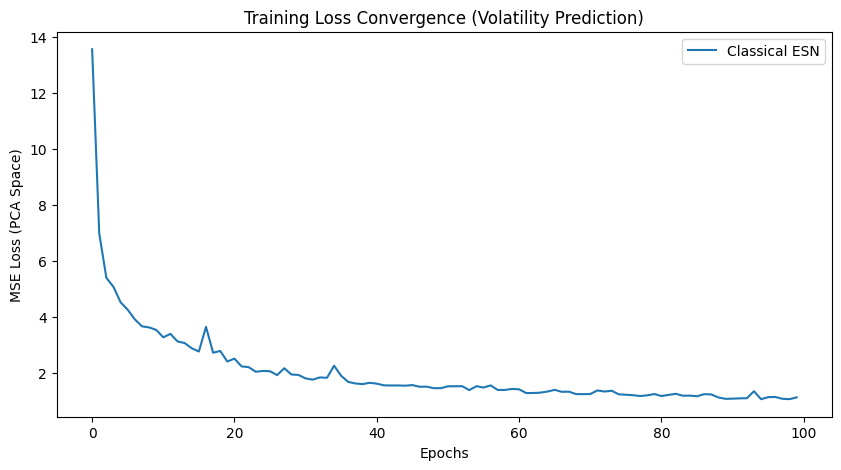

In [209]:
# Assuming you have your PCA-reduced windows in PyTorch Tensors:
train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train), torch.tensor(Y_train))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

n_comp = r # PCA components
n_res = 200

# Initialize models
classical_esn = ClassicalESN(n_comp, n_res, n_comp)
# For the hackathon, a 'Quantum' reservoir would replace W_res with a MerLin layer
# but you can simulate the complexity by changing initialization/sparsity.

# Train
print("Training Classical ESN...")
esn_history, _, __ = train_model(classical_esn, train_loader, epochs=100)

# 3. Visualization of Results
plt.figure(figsize=(10, 5))
plt.plot(esn_history, label='Classical ESN')
plt.title('Training Loss Convergence (Volatility Prediction)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (PCA Space)')
plt.legend()
plt.show()

In [210]:
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test), torch.tensor(Y_test))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

In [211]:
classical_esn.eval()

criterion = nn.MSELoss()

y_test_preds = []
y_test_true = []

for x_batch, y_batch in test_loader:
    output = classical_esn(x_batch)
    loss = criterion(output, y_batch)

    # print("loss:", loss)

    Y_pred_np = output.detach().numpy()
    Y_test_np = y_batch.cpu().numpy()

    y_test_preds.append(Y_pred_np)
    y_test_true.append(Y_test_np)

    # Inverse PCA
    Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np)
    Y_test_surface_scaled = pca.inverse_transform(Y_test_np)
    # print("Y_pred_surface_scaled.shape:", Y_pred_surface_scaled.shape)

    # Undo scaling
    Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
    Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

    surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)

    # print("Surface MSE:", surface_mse)

print(criterion(torch.tensor(y_test_preds), torch.tensor(y_test_true)))

tensor(5.2247)


# The quantum circuit

In [212]:
from merlin import ComputationSpace, MeasurementStrategy, QuantumLayer, LexGrouping

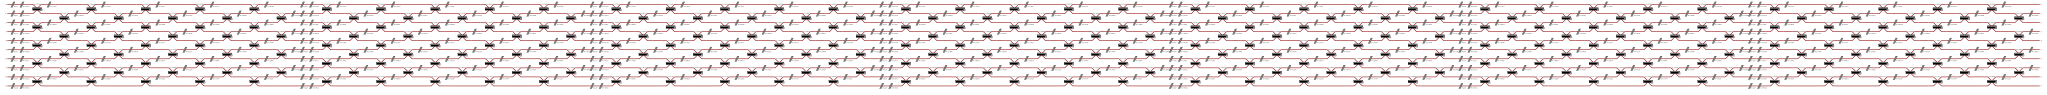

In [213]:
def create_vqc_bs_mesh(m, type=1, depth=None, extra=None):
    """Create variational quantum classifier with specified number of modes using beam splitter meshes"""
    c = pcvl.Circuit(m)

    if type == 1:
        # BS based circuits from https://perceval.quandela.net/docs/v0.13/notebooks/BS-based_implementation.html
        # bs_l = pcvl.GenericInterferometer(
        #     m,
        #     lambda idx: (
        #         pcvl.BS(theta=np.pi * 2 * random.random())
        #         // (0, pcvl.PS(phi=np.pi * 2 * random.random()))
        #     ),
        #     shape=pcvl.InterferometerShape.TRIANGLE,
        #     depth=2 * m,
        #     phase_shifter_fun_gen=lambda idx: pcvl.PS(phi=np.pi * 2 * random.random()),
        # )

        bs_l = pcvl.GenericInterferometer(
            m if not depth else depth,
            lambda idx: (
                pcvl.BS(theta=np.pi * 2 * random.random())
                // (0, pcvl.PS(phi=np.pi * 2 * random.random()))
            ),
            shape=pcvl.InterferometerShape.RECTANGLE,
            depth=m,
            phase_shifter_fun_gen=lambda idx: pcvl.PS(phi=np.pi * 2 * random.random()),
        )

        # Central part of the circuit encodes our data
        c_var = pcvl.Circuit(m)
        for i in range(m):
            px = pcvl.P(f"px{i + 1}")
            # c_var.add(i + (m - 2) // 2, pcvl.PS(px))
            c_var.add(i, pcvl.PS(px))

        # # Other BS mesh
        # bs_r = pcvl.GenericInterferometer(
        #     m,
        #     lambda idx: (
        #         pcvl.BS(theta=pcvl.P(f"theta_r{idx}"))
        #         // (0, pcvl.PS(phi=np.pi * 2 * random.random()))
        #     ),
        #     shape=pcvl.InterferometerShape.RECTANGLE,
        #     depth=2 * m,
        #     phase_shifter_fun_gen=lambda idx: pcvl.PS(phi=np.pi * 2 * random.random()),
        # )

        c.add(0, c_var, merge=True)
        c.add(0, bs_l, merge=True)
        # c.add(0, bs_r, merge=True)
    
    elif type == 2:
        bs_l = pcvl.GenericInterferometer(
            m if not depth else depth,
            lambda idx: (
                pcvl.BS(theta=np.pi * 2 * random.random())
                // (0, pcvl.PS(phi=np.pi * 2 * random.random()))
            ),
            shape=pcvl.InterferometerShape.RECTANGLE,
            depth=m,
            phase_shifter_fun_gen=lambda idx: pcvl.PS(phi=np.pi * 2 * random.random()),
        )
        
        for history_idx in range(window):
            # Central part of the circuit encodes our data
            c_var = pcvl.Circuit(m)
            for i in range(m):
                px = pcvl.P(f"px{history_idx*m + i + 1}")
                # c_var.add(i + (m - 2) // 2, pcvl.PS(px))
                c_var.add(i, pcvl.PS(px))
            
            c.add(0, c_var, merge=True)
            c.add(0, bs_l, merge=True)
    
    elif type == 3:
        bs_l = pcvl.GenericInterferometer(
            m if not depth else depth,
            lambda idx: (
                pcvl.BS(theta=np.pi * 2 * random.random())
                // (0, pcvl.PS(phi=np.pi * 2 * random.random()))
            ),
            shape=pcvl.InterferometerShape.RECTANGLE,
            depth=m,
            phase_shifter_fun_gen=lambda idx: pcvl.PS(phi=np.pi * 2 * random.random()),
        )
        
        for history_idx in range(window):
            # Central part of the circuit encodes our data
            c_var = pcvl.Circuit(m)
            for i in range(extra[0]):
                px = pcvl.P(f"px{history_idx*extra[0] + i + 1}")
                # c_var.add(i + (m - 2) // 2, pcvl.PS(px))
                c_var.add(i, pcvl.PS(px))
            
            c.add(0, c_var, merge=True)
            c.add(0, bs_l, merge=True)

    return c


def count_parameters(model):
    """Count trainable parameters in a PyTorch model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# In our case, we use 3 modes to have the same experiment set-up as the paper
vqc_bs_mesh = create_vqc_bs_mesh(10, type=2, depth=None, extra=[5])
# Let's visualize our circuit
pcvl.pdisplay(vqc_bs_mesh)

In [214]:
class ScaleLayer(nn.Module):
    """
    Multiply the input tensor by a learned or fixed factor.

    Args:
        dim (int): Dimension of the input data to be encoded.
        scale_type (str): Type of scaling method.

    Returns: nn.Module that multiplies the input tensor by a learned or fixed factor.
    """

    def __init__(self, dim, scale_type="learned"):
        super().__init__()
        # Create a single learnable parameter (initialized to 1.0 by default)
        if scale_type == "learned":
            self.scale = nn.Parameter(torch.rand(dim))
        elif scale_type == "2pi":
            self.scale = torch.full((dim,), 2 * torch.pi)
        elif scale_type == "pi":
            self.scale = torch.full((dim,), torch.pi)
        elif scale_type == "/pi":
            self.scale = torch.full((dim,), 1 / torch.pi)
        elif scale_type == "1":
            self.scale = torch.full((dim,), 1)

    def forward(self, x):
        # Element-wise multiplication of each input element by the learned scale
        return x * self.scale

In [215]:
# def get_vqc(m, initial_state, input_size, no_bunching=False, activation="none", scale_type="1"):
# This circuit is as close of representation from the paper. Separate instances of the circuit
class ReservoirCircuit(nn.Module):
    def __init__(self, m, initial_state, input_size, hidden_size, data_size, no_bunching=False, activation="none", scale_type="1", reservoir_type=1):
        super().__init__()
        """Build and return the hybrid model used for binary classification of 2D data"""

        # Get vqc circuit
        vqc_circuit = create_vqc_bs_mesh(m)
        n_photons = torch.sum(torch.tensor(initial_state))
        if no_bunching:
            # No bunching: C(n_modes, n_photons)
            comb(m, n_photons)
        else:
            # With bunching: C(n_modes + n_photons - 1, n_photons)
            comb(m + n_photons - 1, n_photons)

        self.input_layer = ScaleLayer(input_size, scale_type=scale_type)
        self.vqc = QuantumLayer(
            input_size=input_size,
            circuit=vqc_circuit,
            # trainable_parameters=[
            #     p.name for p in vqc_circuit.get_parameters() if not p.name.startswith("px")
            # ],
            trainable_parameters=[],
            input_parameters=["px"],
            input_state=initial_state,  # [1, 0, 0] for example
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED
                if no_bunching
                else ComputationSpace.FOCK
            ),
        )

        self.activation = activation
        self.reservoir_type = reservoir_type
        self.hidden_size = hidden_size

        self.pre_req = nn.Sequential(self.input_layer, self.vqc)
        # self.mid_reservoir = nn.Linear(self.vqc.output_size, input_size//2)
        # self.mid_reservoir = nn.Linear(self.vqc.output_size, hidden_size)
        self.mid_reservoir = nn.Sequential(
            nn.Linear(self.vqc.output_size, 16),
            nn.ReLU(),
            nn.Linear(16, hidden_size),
            nn.ReLU()
        )
        self.input_size = input_size

        # self.res_final = nn.Linear(self.vqc.output_size, self.input_size//2)
        self.res_final = nn.Linear(hidden_size, data_size)
    
    def forward(self, x):
        # x = x[0]
        shape_input = x.shape  # shaoe of x is going to be (window_size, num_PCA_feats)
        batch_size = shape_input[0]
        window_size = shape_input[1]
        num_PCA_feats = shape_input[2]

        if self.reservoir_type == 1:
            # h_time = torch.zeros(1, num_PCA_feats)
            h_time = torch.zeros((batch_size, self.hidden_size))
            for window_idx in range(window_size):
                # y_time = torch.unsqueeze(x[window_idx], 0)
                y_time = x[:, window_idx, :]
                # print("y_time:", y_time)
                # print("h_time:", h_time)
                
                # print(y_time.shape, h_time.shape)
                y_time = torch.cat((y_time, h_time), dim=-1) # , torch.tensor([window_idx/window_size])
                y_time__ = self.pre_req(y_time)
                # print(y_time__.shape)

                # y_time_ = self.mid_reservoir(y_time__)
                h_time = self.mid_reservoir(y_time__)

                # print(y_time_.shape)
                # print(y_time_)
                # h_time = torch.squeeze(y_time_, dim=0)

        # The last Linear layer acts as the observable, and it makes sure the output is 1 dimensional
        if self.activation == "none":
            # complete_vqc = self.res_final(y_time__)
            complete_vqc = self.res_final(h_time)
            
            # complete_vqc = nn.Sigmoid()(complete_vqc)
            # complete_vqc = y_time_

        elif self.activation == "none_":
            classification_layer = nn.Linear(self.vqc.output_size, 1)
            complete_vqc = nn.Sequential(self.input_layer, self.vqc, classification_layer)

        elif self.activation == "sigmoid":
            classification_layer = nn.Linear(self.vqc.output_size, 1)
            complete_vqc = nn.Sequential(
                self.input_layer, self.vqc, classification_layer, nn.Sigmoid()
            )

        elif self.activation == "softmax":
            classification_layer = nn.Linear(self.vqc.output_size, 2)
            complete_vqc = nn.Sequential(
                self.input_layer, self.vqc, classification_layer, nn.Softmax(dim=1)
            )

        else:
            raise ValueError(
                f"Activation function unknown or not implemented: '{self.activation}'"
            )
        
        return complete_vqc

In [216]:
# # def get_vqc(m, initial_state, input_size, no_bunching=False, activation="none", scale_type="1"):
# # This circuit is as close of representation from the paper. Separate instances of the circuit
# class ReservoirCircuit__Ridge(nn.Module):
#     def __init__(self, m, initial_state, input_size, hidden_size, data_size, no_bunching=False, activation="none", scale_type="1", reservoir_type=1):
#         super().__init__()
#         """Build and return the hybrid model used for binary classification of 2D data"""

#         # Get vqc circuit
#         vqc_circuit = create_vqc_bs_mesh(m)
#         n_photons = torch.sum(torch.tensor(initial_state))
#         if no_bunching:
#             # No bunching: C(n_modes, n_photons)
#             comb(m, n_photons)
#         else:
#             # With bunching: C(n_modes + n_photons - 1, n_photons)
#             comb(m + n_photons - 1, n_photons)

#         self.input_layer = ScaleLayer(input_size, scale_type=scale_type)
#         self.vqc = QuantumLayer(
#             input_size=input_size,
#             circuit=vqc_circuit,
#             # trainable_parameters=[
#             #     p.name for p in vqc_circuit.get_parameters() if not p.name.startswith("px")
#             # ],
#             trainable_parameters=[],
#             input_parameters=["px"],
#             input_state=initial_state,  # [1, 0, 0] for example
#             measurement_strategy=MeasurementStrategy.probs(
#                 computation_space=ComputationSpace.UNBUNCHED
#                 if no_bunching
#                 else ComputationSpace.FOCK
#             ),
#         )

#         self.activation = activation
#         self.reservoir_type = reservoir_type
#         self.hidden_size = hidden_size

#         self.pre_req = nn.Sequential(self.input_layer, self.vqc)
#         # self.mid_reservoir = nn.Linear(self.vqc.output_size, input_size//2)
#         self.mid_reservoir = nn.Linear(self.vqc.output_size, hidden_size)
#         # self.mid_reservoir = nn.Sequential(
#         #     nn.Linear(self.vqc.output_size, 16),
#         #     nn.Linear(16, hidden_size)
#         # )
#         self.input_size = input_size

#         # self.res_final = nn.Linear(self.vqc.output_size, self.input_size//2)
#         self.res_final = nn.Linear(hidden_size, data_size)
    
#     def forward(self, x):
#         x = x[0]
#         shape_input = x.shape  # shaoe of x is going to be (window_size, num_PCA_feats)
#         window_size = shape_input[0]
#         num_PCA_feats = shape_input[1]

#         if self.reservoir_type == 1:
#             # h_time = torch.zeros(1, num_PCA_feats)
#             h_time = torch.zeros(self.hidden_size)
#             for window_idx in range(window_size):
#                 # y_time = torch.unsqueeze(x[window_idx], 0)
#                 y_time = x[window_idx]
#                 print("y_time:", y_time)
#                 # print(y_time.shape, h_time.shape)
#                 y_time = torch.cat((y_time, h_time), dim=0) # , torch.tensor([window_idx/window_size])
#                 y_time__ = self.pre_req(y_time)
#                 # print(y_time__.shape)
#                 y_time_ = self.mid_reservoir(y_time__)
#                 # print(y_time_.shape)
#                 # print(y_time_)
#                 print("h_time:", h_time)
#                 print("y_time_:", y_time_)
#                 h_time = torch.squeeze(y_time_, dim=0)

#         # The last Linear layer acts as the observable, and it makes sure the output is 1 dimensional
#         if self.activation == "none":
#             # complete_vqc = self.res_final(y_time__)
#             complete_vqc = self.res_final(h_time)
            
#             # complete_vqc = nn.Sigmoid()(complete_vqc)
#             # complete_vqc = y_time_

#         elif self.activation == "none_":
#             classification_layer = nn.Linear(self.vqc.output_size, 1)
#             complete_vqc = nn.Sequential(self.input_layer, self.vqc, classification_layer)

#         elif self.activation == "sigmoid":
#             classification_layer = nn.Linear(self.vqc.output_size, 1)
#             complete_vqc = nn.Sequential(
#                 self.input_layer, self.vqc, classification_layer, nn.Sigmoid()
#             )

#         elif self.activation == "softmax":
#             classification_layer = nn.Linear(self.vqc.output_size, 2)
#             complete_vqc = nn.Sequential(
#                 self.input_layer, self.vqc, classification_layer, nn.Softmax(dim=1)
#             )

#         else:
#             raise ValueError(
#                 f"Activation function unknown or not implemented: '{self.activation}'"
#             )
        
#         return complete_vqc

In [217]:
# def get_vqc(m, initial_state, input_size, no_bunching=False, activation="none", scale_type="1"):
# Everything in one circuit
class ReservoirCircuit_FullOne(nn.Module):
    def __init__(self, m, initial_state, input_size, hidden_size, data_size, no_bunching=False, activation="none", scale_type="1", reservoir_type=3, extra=None):
        super().__init__()
        """Build and return the hybrid model used for binary classification of 2D data"""

        # Get vqc circuit
        vqc_circuit = create_vqc_bs_mesh(m, type=reservoir_type, extra=extra)
        n_photons = torch.sum(torch.tensor(initial_state))
        if no_bunching:
            # No bunching: C(n_modes, n_photons)
            comb(m, n_photons)
        else:
            # With bunching: C(n_modes + n_photons - 1, n_photons)
            comb(m + n_photons - 1, n_photons)

        self.input_layer = ScaleLayer(input_size, scale_type=scale_type)
        self.vqc = QuantumLayer(
            input_size=input_size,
            circuit=vqc_circuit,
            # trainable_parameters=[
            #     p.name for p in vqc_circuit.get_parameters() if not p.name.startswith("px")
            # ],
            trainable_parameters=[],
            input_parameters=["px"],
            input_state=initial_state,  # [1, 0, 0] for example
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED
                if no_bunching
                else ComputationSpace.FOCK
                # grouping=LexGrouping(m, 3)
            ),
        )

        self.activation = activation
        self.reservoir_type = reservoir_type
        self.hidden_size = hidden_size

        self.pre_req = nn.Sequential(self.input_layer, self.vqc)
        # # self.mid_reservoir = nn.Linear(self.vqc.output_size, input_size//2)
        # self.mid_reservoir = nn.Linear(self.vqc.output_size, hidden_size)
        self.input_size = input_size

        # self.res_final = nn.Linear(self.vqc.output_size, self.input_size//2)
        # self.res_final = nn.Linear(hidden_size, data_size)
    
    def forward(self, x):
        shape_input = x.shape  # shaoe of x is going to be (window_size, num_PCA_feats)
        # print("shape_input:", shape_input)
        batch_size = shape_input[0]
        window_size = shape_input[1]
        num_PCA_feats = shape_input[2]

        # print("shape of input:", x.shape)
        final = torch.reshape(x, (batch_size, self.input_size))

        # if self.reservoir_type == 1:
        if True:
            final = self.pre_req(final)
            # print("shape of final:", final.shape)

        # The last Linear layer acts as the observable, and it makes sure the output is 1 dimensional
        if self.activation == "none":
            # complete_vqc = self.res_final(y_time__)
            # complete_vqc = self.res_final(h_time)
            
            # complete_vqc = nn.Sigmoid()(complete_vqc)
            # complete_vqc = y_time_
            complete_vqc = final

        elif self.activation == "none_":
            classification_layer = nn.Linear(self.vqc.output_size, 1)
            complete_vqc = nn.Sequential(self.input_layer, self.vqc, classification_layer)

        elif self.activation == "sigmoid":
            classification_layer = nn.Linear(self.vqc.output_size, 1)
            complete_vqc = nn.Sequential(
                self.input_layer, self.vqc, classification_layer, nn.Sigmoid()
            )

        elif self.activation == "softmax":
            classification_layer = nn.Linear(self.vqc.output_size, 2)
            complete_vqc = nn.Sequential(
                self.input_layer, self.vqc, classification_layer, nn.Softmax(dim=1)
            )

        else:
            raise ValueError(
                f"Activation function unknown or not implemented: '{self.activation}'"
            )
        
        return complete_vqc

In [218]:
# def get_vqc(m, initial_state, input_size, no_bunching=False, activation="none", scale_type="1"):
# Everything in one circuit
class ReservoirCircuit_FullOne_PerMat(nn.Module):
    def __init__(self, m, initial_state, input_size, hidden_size, data_size, no_bunching=False, activation="none", scale_type="1", reservoir_type=1):
        super().__init__()
        """Build and return the hybrid model used for binary classification of 2D data"""

        # Get vqc circuit
        vqc_circuit = create_vqc_bs_mesh(m, type=2, extra=[m//2])
        n_photons = torch.sum(torch.tensor(initial_state))
        if no_bunching:
            # No bunching: C(n_modes, n_photons)
            comb(m, n_photons)
        else:
            # With bunching: C(n_modes + n_photons - 1, n_photons)
            comb(m + n_photons - 1, n_photons)

        self.input_layer = ScaleLayer(input_size, scale_type=scale_type)
        self.vqc = QuantumLayer(
            input_size=input_size,
            circuit=vqc_circuit,
            # trainable_parameters=[
            #     p.name for p in vqc_circuit.get_parameters() if not p.name.startswith("px")
            # ],
            trainable_parameters=[],
            input_parameters=["px"],
            input_state=initial_state,  # [1, 0, 0] for example
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED
                if no_bunching
                else ComputationSpace.FOCK
                # grouping=LexGrouping(m, 3)
            ),
        )

        self.activation = activation
        self.reservoir_type = reservoir_type
        self.hidden_size = hidden_size

        self.pre_req = nn.Sequential(self.input_layer, self.vqc)
        # # self.mid_reservoir = nn.Linear(self.vqc.output_size, input_size//2)
        # self.mid_reservoir = nn.Linear(self.vqc.output_size, hidden_size)
        self.input_size = input_size

        # self.res_final = nn.Linear(self.vqc.output_size, self.input_size//2)
        # self.res_final = nn.Linear(hidden_size, data_size)
    
    def forward(self, x):
        shape_input = x.shape  # shaoe of x is going to be (window_size, num_PCA_feats)
        # print("shape_input:", shape_input)
        batch_size = shape_input[0]
        window_size = shape_input[1]
        num_maturities = shape_input[2]
        num_PCA_feats = shape_input[3]

        # print("shape of input:", x.shape)

        torch.permute(x, (0, 2, 1, 3))
        final = torch.reshape(x, (batch_size*num_maturities, window_size*num_PCA_feats))

        # if self.reservoir_type == 1:
        if True:
            final = self.pre_req(final)
            # print("shape of final:", final.shape)
        
        final = torch.reshape(final, (batch_size, num_maturities, self.vqc.output_size))

        # The last Linear layer acts as the observable, and it makes sure the output is 1 dimensional
        if self.activation == "none":
            # complete_vqc = self.res_final(y_time__)
            # complete_vqc = self.res_final(h_time)
            
            # complete_vqc = nn.Sigmoid()(complete_vqc)
            # complete_vqc = y_time_
            complete_vqc = final

        elif self.activation == "none_":
            classification_layer = nn.Linear(self.vqc.output_size, 1)
            complete_vqc = nn.Sequential(self.input_layer, self.vqc, classification_layer)

        elif self.activation == "sigmoid":
            classification_layer = nn.Linear(self.vqc.output_size, 1)
            complete_vqc = nn.Sequential(
                self.input_layer, self.vqc, classification_layer, nn.Sigmoid()
            )

        elif self.activation == "softmax":
            classification_layer = nn.Linear(self.vqc.output_size, 2)
            complete_vqc = nn.Sequential(
                self.input_layer, self.vqc, classification_layer, nn.Softmax(dim=1)
            )

        else:
            raise ValueError(
                f"Activation function unknown or not implemented: '{self.activation}'"
            )
        
        return complete_vqc

In [219]:
# def get_mlp_deep(input_size, activation):
#     """Build and return a small 2-hidden-layers MLP for binary classification"""
#     classical_layer_1 = nn.Linear(input_size, 2)
#     classical_layer_2 = nn.Linear(2, 3)

#     if activation == "none":
#         mlp = nn.Sequential(
#             classical_layer_1, nn.ReLU(), classical_layer_2, nn.ReLU(), nn.Linear(3, 1)
#         )

#     elif activation == "sigmoid":
#         mlp = nn.Sequential(
#             classical_layer_1,
#             nn.ReLU(),
#             classical_layer_2,
#             nn.ReLU(),
#             nn.Linear(3, 1),
#             nn.Sigmoid(),
#         )

#     elif activation == "softmax":
#         mlp = nn.Sequential(
#             classical_layer_1,
#             nn.ReLU(),
#             classical_layer_2,
#             nn.ReLU(),
#             nn.Linear(3, 2),
#             nn.Softmax(dim=1),
#         )
#     else:
#         raise ValueError(
#             f"Activation function unknown or not implemented: '{activation}'"
#         )

#     return mlp


# def get_mlp_wide(input_size, activation):
#     """Build and return a small 1-hidden-layers MLP for binary classification"""
#     classical_layer_1 = nn.Linear(input_size, 4)

#     if activation == "none":
#         mlp = nn.Sequential(classical_layer_1, nn.ReLU(), nn.Linear(4, 1))

#     elif activation == "sigmoid":
#         mlp = nn.Sequential(classical_layer_1, nn.ReLU(), nn.Linear(4, 1), nn.Sigmoid())

#     elif activation == "softmax":
#         mlp = nn.Sequential(
#             classical_layer_1, nn.ReLU(), nn.Linear(4, 2), nn.Softmax(dim=1)
#         )
#     else:
#         raise ValueError(
#             f"Activation function unknown or not implemented: '{activation}'"
#         )

#     return mlp

In [220]:
# def train_model(model, model_name, x_train, x_test, y_train, y_test, args):
#     """Train a model and return training metrics"""
#     optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, betas=args.betas)
#     criterion = nn.MSELoss()  # loss from paper

#     losses = []
#     train_accuracies = []
#     test_accuracies = []

#     model.train()

#     pbar = tqdm(range(args.n_epochs), desc=f"Training {model_name}")
#     for _epoch in pbar:
#         permutation = torch.randperm(x_train.size()[0])
#         total_loss = 0

#         for i in range(0, x_train.size()[0], args.batch_size):
#             indices = permutation[i : i + args.batch_size]
#             batch_x, batch_y = x_train[indices], y_train[indices]

#             # If softmax activation, we have to format the labels in 2-dimensions
#             if args.activation == "softmax":
#                 # One-hot encode
#                 batch_y = functional.one_hot(
#                     batch_y.squeeze().long(), num_classes=2
#                 ).float()  # shape : (batch_size, 2)

#             outputs = model(batch_x)

#             # Get the right parameters for regularization
#             if args.regu_on == "linear":
#                 # Get the observable parameters
#                 if args.activation == "none":
#                     obs = list(model[-1].parameters())
#                 else:
#                     obs = list(model[-2].parameters())
#                 # Flatten all tensors and concatenate into a single vector
#                 obs_vector = torch.cat([p.view(-1) for p in obs])

#             elif args.regu_on == "all":
#                 # Get the observable parameters
#                 obs = list(model.parameters())
#                 # Flatten all tensors and concatenate into a single vector
#                 obs_vector = torch.cat([p.view(-1) for p in obs])

#             else:
#                 raise NotImplementedError

#                 #  [                      MSE                    ] + [                regularization                    ]
#             loss = (
#                 criterion(outputs.squeeze(), batch_y.squeeze())
#                 + args.alpha * torch.linalg.vector_norm(obs_vector) ** 2
#             )

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item()

#         avg_loss = total_loss / (x_train.size()[0] // args.batch_size)
#         losses.append(avg_loss)

#         # Evaluation
#         model.eval()
#         with torch.no_grad():
#             train_outputs = model(x_train)

#             if args.activation == "softmax":
#                 train_preds = torch.argmax(train_outputs, dim=1)
#             else:
#                 train_preds = torch.round(train_outputs)

#             train_acc = accuracy_score(y_train.numpy(), train_preds.cpu().numpy())
#             train_accuracies.append(train_acc)

#             test_outputs = model(x_test)

#             if args.activation == "softmax":
#                 test_preds = torch.argmax(test_outputs, dim=1)
#             else:
#                 test_preds = torch.round(test_outputs)

#             test_acc = accuracy_score(y_test.numpy(), test_preds)
#             test_accuracies.append(test_acc)

#             pbar.set_description(
#                 f"Training {model_name} - Loss: {avg_loss:.4f}, Test Acc: {test_acc:.4f}"
#             )

#         model.train()

#     return {
#         "losses": losses,
#         "train_accuracies": train_accuracies,
#         "test_accuracies": test_accuracies,
#         "final_test_acc": test_accuracies[-1],
#     }

In [221]:
# def train_model_multiple_runs(type, args):
#     """
#     Train model multiple times and return results

#     Parameters
#     ----------
#     type : String, must be in this list ["vqc", "mlp_deep", "mlp_wide", "svm_lin", "svm_rbf"]
#         Indicates which type of model to train.

#     args : Arguments object
#         Contains arguments passed to the model or useful for training

#     Returns
#     -------
#     Dictionary
#         Contains the results of several runs of the model.
#     """

#     x_trains, x_tests, y_trains, y_tests = prepare_data()
#     datasets = ["linear", "circular", "moon"]
#     best_models = []
#     best_accs = []
#     results = {}

#     for i, dataset in enumerate(datasets):
#         x_train = x_trains[i]
#         x_test = x_tests[i]
#         y_train = y_trains[i]
#         y_test = y_tests[i]

#         if type == "vqc":
#             print(f"\nTraining VQC with dataset {dataset} ({args.num_runs} runs):")
#             models = []
#             model_runs = []

#             for run in range(args.num_runs):
#                 # Create a fresh instance of the model for each run
#                 model = get_vqc(
#                     args.m,
#                     args.initial_state,
#                     activation=args.activation,
#                     no_bunching=args.no_bunching,
#                     scale_type=args.scale_type,
#                 )
#                 num_params = count_parameters(model)

#                 print(
#                     f"  Run {run + 1}/{args.num_runs}, VQC has {num_params} parameters..."
#                 )
#                 args.set_dataset_name(dataset)

#                 run_results = train_model(
#                     model,
#                     f"VQC with dataset {dataset} (run{run + 1})",
#                     x_train,
#                     x_test,
#                     y_train,
#                     y_test,
#                     args,
#                 )
#                 models.append(model)
#                 model_runs.append(run_results)

#         elif type[:3] == "mlp":
#             if type == "mlp_wide":
#                 network_type = "wide"
#                 get_mlp = get_mlp_wide
#             elif type == "mlp_deep":
#                 network_type = "deep"
#                 get_mlp = get_mlp_deep
#             else:
#                 raise NotImplementedError

#             print(
#                 f"\nTraining MLP ({network_type}) with dataset {dataset} ({args.num_runs} runs):"
#             )
#             models = []
#             model_runs = []

#             for run in range(args.num_runs):
#                 # Create a fresh instance of the model for each run
#                 model = get_mlp(2, activation=args.activation)

#                 num_params = count_parameters(model)

#                 print(
#                     f"  Run {run + 1}/{args.num_runs}, MLP has {num_params} parameters..."
#                 )
#                 args.set_dataset_name(dataset)
#                 run_results = train_model(
#                     model,
#                     f"MLP with dataset {dataset} (run{run + 1})",
#                     x_train,
#                     x_test,
#                     y_train,
#                     y_test,
#                     args,
#                 )
#                 models.append(model)
#                 model_runs.append(run_results)

#         else:
#             if type == "svm_lin":
#                 kernel = "linear"
#             elif type == "svm_rbf":
#                 kernel = "rbf"
#             else:
#                 raise NotImplementedError

#             print(
#                 f"\nTraining SVM ({kernel}) with dataset {dataset} ({args.num_runs} runs):"
#             )
#             models = []
#             model_runs = []

#             for run in range(args.num_runs):
#                 # Create a fresh instance of the model for each run
#                 model = SVC(kernel=kernel, gamma="scale")
#                 model.fit(x_train, y_train)

#                 print(f"  Run {run + 1}/{args.num_runs}, SVM ({kernel})...")
#                 args.set_dataset_name(dataset)

#                 y_pred = model.predict(x_test)
#                 accuracy = accuracy_score(y_test, y_pred)
#                 models.append(model)
#                 run_results = {
#                     "losses": [0.0] * args.n_epochs,
#                     "train_accuracies": [0.0] * args.n_epochs,
#                     "test_accuracies": [0.0] * args.n_epochs,
#                     "final_test_acc": accuracy,
#                 }
#                 model_runs.append(run_results)

#         best_run = torch.argmax(
#             torch.Tensor([run["final_test_acc"] for run in model_runs])
#         )
#         best_accs.append(
#             torch.max(torch.Tensor([run["final_test_acc"] for run in model_runs]))
#         )
#         best_models.append(models[best_run])

#         # Store all runs for this model
#         results[dataset] = {
#             "runs": model_runs,
#             # Calculate aggregate statistics
#             "avg_final_test_acc": sum(run["final_test_acc"] for run in model_runs)
#             / args.num_runs,
#         }

#     # visualize_decision_boundary(
#     #     type, best_models, x_trains, x_tests, y_trains, y_tests, args, best_accs
#     # )

#     return results


# def train_vqc_multiple_runs(args):
#     """Train VQC several times"""
#     return train_model_multiple_runs("vqc", args)

In [225]:
# Hyperparameters and experimental set-up
m = 7

# initial_state = [1, 1, 1, 1, 1]
# initial_state = [1, 1, 1, 1, 1, 0, 0, 0, 0, 1]
# initial_state = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
# initial_state = [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
# initial_state = [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
initial_state = [1, 1, 1, 1, 1, 1, 1]

activation = "none"  # ["none", "sigmoid", "softmax"]
no_bunching = False
num_runs = 5
n_epochs = 150
batch_size = 30
lr = 0.02
alpha = 0.0002
betas = (0.8, 0.999)
scale_type = "1"  # ["learned", "2pi", "pi", "/pi", "1"]
regu_on = "linear"  # ["linear", "all"]

# input_size = 10
input_size = 49

# hidden_size = 5
hidden_size = 0

data_size = r

In [226]:
# class Arguments:
#     def __init__(
#         self,
#         m,
#         initial_state,
#         activation="none",
#         no_bunching=False,
#         num_runs=5,
#         n_epochs=50,
#         batch_size=32,
#         lr=0.02,
#         alpha=0.2,
#         betas=(0.9, 0.999),
#         scale_type="learned",
#         regu_on="linear",
#     ):
#         self.m = m
#         self.initial_state = initial_state
#         self.activation = activation
#         self.no_bunching = no_bunching
#         self.num_runs = num_runs
#         self.n_epochs = n_epochs
#         self.batch_size = batch_size
#         self.lr = lr
#         self.alpha = alpha
#         self.betas = betas
#         self.scale_type = scale_type
#         self.regu_on = regu_on
#         self.dataset_name = ""

#     def set_dataset_name(self, dataset):
#         self.dataset_name = dataset
#         return

In [227]:
# # VQC [1, 0, 0]
# args = Arguments(
#     m,
#     initial_state,
#     activation,
#     no_bunching,
#     num_runs,
#     n_epochs,
#     batch_size,
#     lr,
#     alpha,
#     betas,
#     scale_type,
#     regu_on,
# )

In [228]:
train_dataset__per_maturity = torch.utils.data.TensorDataset(torch.tensor(X_train__per_maturity), torch.tensor(Y_train__per_maturity))
train_loader__per_maturity = torch.utils.data.DataLoader(train_dataset__per_maturity, batch_size=32, shuffle=True)

In [229]:
test_dataset__per_maturity = torch.utils.data.TensorDataset(torch.tensor(X_test__per_maturity), torch.tensor(Y_test__per_maturity))
test_loader__per_maturity = torch.utils.data.DataLoader(test_dataset__per_maturity, batch_size=1, shuffle=False)

In [230]:
# vqc_100_results = train_vqc_multiple_runs(args)

In [237]:
n_comp = r # PCA components
n_res = 200

# QuantumRes = ReservoirCircuit(m, initial_state, input_size, hidden_size, data_size, no_bunching=False, activation="none", scale_type="1", reservoir_type=1)
QuantumRes = ReservoirCircuit_FullOne(m, initial_state, input_size, hidden_size, data_size, no_bunching=False, activation="none", scale_type="2pi", reservoir_type=2, extra=[m//2])
# QuantumRes = ReservoirCircuit_FullOne_PerMat(m, initial_state, input_size, hidden_size, data_size, no_bunching=False, activation="none", scale_type="pi", reservoir_type=1)

In [238]:
count_parameters(QuantumRes)

0

Training Quantum Reservoir...
shapes mid: (388, 1716) (388, 7)
Readout Type         | PCA MSE      | Real Space MSE 
-------------------------------------------------------
shape of predictions_np: (388, 7)
shape of Y_targets: (388, 7)
Ridge (L2) Training Complete | Final MSE: 14.1652650833 | Surface MSE in real space: 0.0001814201
Ridge (L2) Training Complete | Final RMSE: 3.7636771202 | Surface RMSE in real space: 0.0134692263
Ridge (L2) Training Complete | Final MAE: 1.8481009007 | Surface MAE in real space: 0.0101704419
shape of predictions_np: (388, 7)
shape of Y_targets: (388, 7)
Linear Regression Training Complete | Final MSE: 0.0000000001 | Surface MSE in real space: 0.0000000000
Linear Regression Training Complete | Final RMSE: 0.0000107118 | Surface RMSE in real space: 0.0000000384
Linear Regression Training Complete | Final MAE: 0.0000052195 | Surface MAE in real space: 0.0000000282
shape of predictions_np: (388, 7)
shape of Y_targets: (388, 7)
Random Forest Training Complet

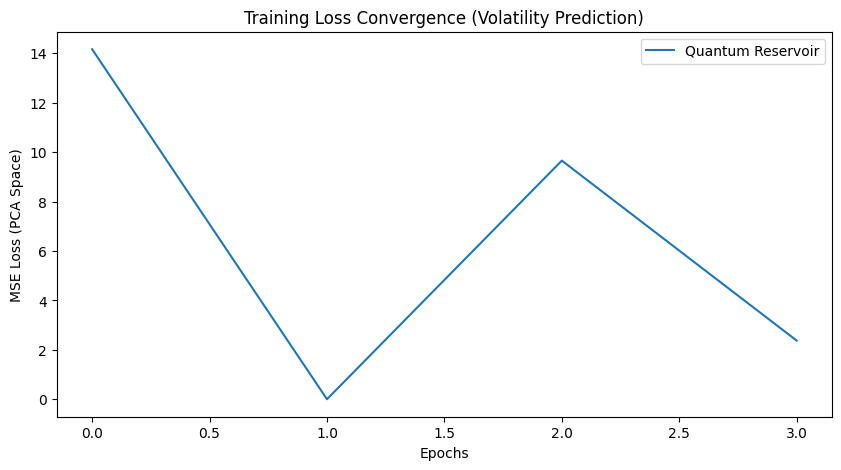

In [239]:
# For the hackathon, a 'Quantum' reservoir would replace W_res with a MerLin layer
# but you can simulate the complexity by changing initialization/sparsity.

# Train
print("Training Quantum Reservoir...")

# esn_history, Y_pred_train, Y_real_train = train_model(QuantumRes, train_loader, epochs=200, lr=0.001, no_optimizer=True)
# esn_history, Y_pred_train, Y_real_train, final_ridge = train_model__ridge(QuantumRes, train_loader, epochs=1, lr=0.001, no_optimizer=True, norm_on_PCA=True)
# esn_history, Y_pred_train, Y_real_train, final_readouts = train_model__ridge(QuantumRes, train_loader__per_maturity, epochs=1, lr=0.001, no_optimizer=True, norm_on_PCA=False)
esn_history, Y_pred_train, Y_real_train, final_readouts = train_model__ridge(QuantumRes, train_loader, epochs=1, lr=0.001, no_optimizer=True, norm_on_PCA=False)
# esn_history, Y_pred_train, Y_real_train, final_readouts = train_model__ridge__per_maturity(QuantumRes, train_loader__per_maturity, epochs=1, lr=0.001, no_optimizer=True, 
#                                                                                            norm_on_PCA=True, pca=pca__per_maturity, scaler=scaler_per_maturity)

# 3. Visualization of Results
plt.figure(figsize=(10, 5))
plt.plot(esn_history, label='Quantum Reservoir')
plt.title('Training Loss Convergence (Volatility Prediction)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (PCA Space)')
plt.legend()
plt.show()

In [240]:
final_readouts
# final_ridge

{'Ridge (L2)': Ridge(alpha=0.001),
 'Linear Regression': LinearRegression(),
 'Random Forest': RandomForestRegressor(max_depth=7, random_state=42),
 'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42)}

In [241]:
# for per-maturity
# evaluation ontest dataset for ridge
model = QuantumRes

history = []
y_pred_train__inference = []
y_real_train__inference = []

for x_batch, y_batch in test_loader__per_maturity:
    # the norma logic
    B, W, M, F = x_batch.shape
    x_np = x_batch.cpu().numpy().reshape(-1, F)
    x_norm = Normalizer(norm='l2').transform(x_np)
    x_batch = torch.tensor(x_norm.reshape(B, W, M, F), dtype=torch.float32)

    output = model(x_batch)

    pred_flat = output.detach().cpu().numpy()
    real_flat = y_batch.detach().cpu().numpy()
    
    y_pred_train__inference.append(pred_flat)
    y_real_train__inference.append(real_flat)

    # print(pred_flat.shape)

X_states = np.concatenate(y_pred_train__inference, axis=0) # (N_samples, VQC_output_dim)
Y_targets = np.concatenate(y_real_train__inference, axis=0)

# print(X_states.shape, Y_targets.shape)

predictions_np__all_readouts__per_maturity = {}

for name, clfs in final_readouts.items():

    predictions_nps = []
    Y_pred_surfaces = []
    Y_test_surfaces = []

    for clf_idx, clf in enumerate(clfs):
        predictions_np = clf.predict(X_states[:, clf_idx, :])
        predictions_nps.append(predictions_np)

        # predictions_np__all_readouts[name] = predictions_np

        # print("shape of predictions_np:", predictions_np.shape)
        # print("shape of Y_targets:", Y_targets.shape)

        # Calculate final MSE
        # final_loss = np.mean((predictions_np - Y_targets)**2)
        # history.append(final_loss)

        # Convert back to list of tensors to match your original return signature
        y_pred_train = [torch.tensor(p) for p in predictions_np]
        y_real_train = [torch.tensor(y) for y in Y_targets[:, clf_idx, :]]

        Y_test_surface_scaled = pca.inverse_transform(y_real_train)
        Y_pred_surface_scaled = pca.inverse_transform(y_pred_train)
        # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

        # Undo scaling
        Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
        Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

        Y_pred_surfaces.append(Y_pred_surface)
        Y_test_surfaces.append(Y_test_surface)

        # surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)
        # # print(f"Ridge Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
        # print(f"{name} Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
    
    predictions_nps = np.array(predictions_nps)
    predictions_nps = predictions_nps.reshape(predictions_nps.shape[1], predictions_nps.shape[0], predictions_nps.shape[2])
    Y_pred_surfaces = np.array(Y_pred_surfaces)
    Y_test_surfaces = np.array(Y_test_surfaces)

    final_loss = np.mean((predictions_nps - Y_targets)**2)
    final_loss_rmse = np.sqrt(final_loss)
    surface_mse = np.mean((Y_pred_surfaces - Y_test_surfaces)**2)
    surface_rmse = np.sqrt(np.mean((Y_pred_surfaces - Y_test_surfaces)**2))

    print(f"{name} Training Complete | Final MSE: {np.mean(final_loss):.10f} | Surface MSE in real space: {np.mean(surface_mse):.10f}")
    print(f"{name} Training Complete | Final RMSE: {np.mean(final_loss_rmse):.10f} | Surface RMSE in real space: {np.mean(surface_rmse):.10f}")

    predictions_np__all_readouts__per_maturity[name] = predictions_nps

RuntimeError: shape '[1, 49]' is invalid for input of size 784

In [242]:
# evaluation ontest dataset for ridge
# for not per-maturity
model = QuantumRes

history = []
y_pred_train__inference = []
y_real_train__inference = []

for x_batch, y_batch in test_loader:
    # the norma logic
    B, W, F = x_batch.shape
    x_np = x_batch.cpu().numpy().reshape(-1, F)
    x_norm = Normalizer(norm='l2').transform(x_np)
    x_batch = torch.tensor(x_norm.reshape(B, W, F), dtype=torch.float32)

    output = model(x_batch)

    pred_flat = output.detach().cpu().numpy()
    real_flat = y_batch.detach().cpu().numpy()
    
    y_pred_train__inference.append(pred_flat)
    y_real_train__inference.append(real_flat)

    # print(pred_flat.shape)

X_states = np.concatenate(y_pred_train__inference, axis=0) # (N_samples, VQC_output_dim)
Y_targets = np.concatenate(y_real_train__inference, axis=0)

# print(X_states.shape, Y_targets.shape)

predictions_np__all_readouts = {}

for name, clf in final_readouts.items():
    predictions_np = clf.predict(X_states)
    predictions_np__all_readouts[name] = predictions_np

    # print("shape of predictions_np:", predictions_np.shape)
    # print("shape of Y_targets:", Y_targets.shape)

    # Calculate final MSE
    final_loss = np.mean((predictions_np - Y_targets)**2)
    final_loss_rmse = np.sqrt(final_loss)
    final_loss_mae = np.mean(np.abs(predictions_np - Y_targets))

    history.append(final_loss)

    # Convert back to list of tensors to match your original return signature
    y_pred_train = [torch.tensor(p) for p in predictions_np]
    y_real_train = [torch.tensor(y) for y in Y_targets]

    Y_test_surface_scaled = pca.inverse_transform(y_real_train)
    Y_pred_surface_scaled = pca.inverse_transform(y_pred_train)
    # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

    # Undo scaling
    Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
    Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

    surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)
    surface_mse_rmse = np.sqrt(surface_mse)
    surface_mse_mae = np.mean(np.abs(Y_pred_surface - Y_test_surface))

    # print(f"Ridge Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
    print(f"{name} Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
    print(f"{name} Training Complete | Final RMSE: {final_loss_rmse:.6f} | Surface RMSE in real space: {surface_mse_rmse:.6f}")
    print(f"{name} Training Complete | Final MAE: {final_loss_mae:.6f} | Surface MAE in real space: {surface_mse_mae:.6f}")
    print("----------")

Ridge (L2) Training Complete | Final MSE: 35.432453 | Surface MSE in real space: 0.000401
Ridge (L2) Training Complete | Final RMSE: 5.952517 | Surface RMSE in real space: 0.020029
Ridge (L2) Training Complete | Final MAE: 2.900910 | Surface MAE in real space: 0.015249
----------
Linear Regression Training Complete | Final MSE: 53.491108 | Surface MSE in real space: 0.000631
Linear Regression Training Complete | Final RMSE: 7.313762 | Surface RMSE in real space: 0.025122
Linear Regression Training Complete | Final MAE: 3.487350 | Surface MAE in real space: 0.018362
----------
Random Forest Training Complete | Final MSE: 32.510781 | Surface MSE in real space: 0.000369
Random Forest Training Complete | Final RMSE: 5.701823 | Surface RMSE in real space: 0.019202
Random Forest Training Complete | Final MAE: 2.722284 | Surface MAE in real space: 0.014960
----------
Decision Tree Training Complete | Final MSE: 74.803220 | Surface MSE in real space: 0.000906
Decision Tree Training Complete | 

In [159]:
QuantumRes.eval()

criterion = nn.MSELoss()

y_test_preds = []
y_test_true = []

y_test_preds_ = []
y_test_true_ = []

for x_batch, y_batch in test_loader:
    output = QuantumRes(x_batch)

    # loss = criterion(output, y_batch)
    # loss = criterion(output.view(-1), y_batch.view(-1))

    # print("loss:", loss)

    Y_pred_np = output.detach().numpy()
    Y_test_np = y_batch.cpu().numpy()

    # print(Y_pred_np.shape)

    y_test_preds.append(Y_pred_np)
    y_test_true.append(Y_test_np)

    # Inverse PCA
    # Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np)
    Y_test_surface_scaled = pca.inverse_transform(Y_test_np)
    # Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np.reshape(1, -1))
    Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np.reshape(1, -1))
    # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

    # Undo scaling
    Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
    Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

    y_test_preds_.append(Y_pred_surface)
    y_test_true_.append(Y_test_surface)

    surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)

    # print("Surface MSE:", surface_mse)

# print(torch.tensor(y_test_preds).shape, torch.tensor(y_test_true).shape)

print(criterion(torch.tensor(y_test_preds), torch.tensor(y_test_true)))
print(np.mean((np.array(y_test_preds_) - np.array(y_test_true_))**2))

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 126)

In [160]:
# torch.tensor(y_test_preds).shape, torch.tensor(y_test_true).shape
torch.tensor(predictions_np).shape, torch.tensor(y_real_train__inference).shape

(torch.Size([92, 5]), torch.Size([92, 1, 5]))

In [161]:
len(y_test_preds)

1

In [162]:
# PCA_idx = 4
for name, predictions_np in predictions_np__all_readouts.items():
# for name, predictions_np in predictions_np__all_readouts__per_maturity.items():
    # print("predictions_np shape:", predictions_np.shape)
    # print(torch.tensor(y_test_true).shape)
    # print(Y_targets.shape)
    print(f"-----For {name}-----")
    for PCA_idx in range(n_comp):
        # print(criterion(torch.tensor(y_test_preds)[:, PCA_idx], torch.tensor(y_test_true)[:, 0, PCA_idx]))
        print(criterion(torch.tensor(predictions_np)[:, PCA_idx], torch.tensor(y_test_true)[:, 0, PCA_idx]))
        # print(criterion(torch.tensor(predictions_np)[:, PCA_idx], torch.tensor(Y_targets)[:, PCA_idx]))

-----For Ridge (L2)-----
tensor(393.4925)
tensor(41.6562)
tensor(19.3630)
tensor(0.1248)
tensor(0.0117)
-----For Linear Regression-----
tensor(404.1172)
tensor(45.6309)
tensor(20.7476)
tensor(0.1300)
tensor(0.0135)
-----For Random Forest-----
tensor(299.6497, dtype=torch.float64)
tensor(23.9429, dtype=torch.float64)
tensor(6.8085, dtype=torch.float64)
tensor(0.1181, dtype=torch.float64)
tensor(0.0008, dtype=torch.float64)
-----For Decision Tree-----
tensor(414.1318, dtype=torch.float64)
tensor(53.9736, dtype=torch.float64)
tensor(15.6144, dtype=torch.float64)
tensor(0.1840, dtype=torch.float64)
tensor(0.0160, dtype=torch.float64)


/Users/soardr/Q-volution 2026/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([92])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [163]:
n_components = r
split_idx = len(Y_train)

In [164]:
len(Y_train), len(Y_test)

(388, 92)

In [165]:
# len(Y_real_train)
# Y_real_train[1].shape
Y_pred_train[1].shape

# len(Y_real_train)
len(Y_pred_train)

388

In [166]:
Y_real_train__last_epoch = Y_real_train[-392:]
Y_pred_train__last_epoch = Y_pred_train[-392:]

In [167]:
type(Y_pred_train__last_epoch)

list

In [168]:
# Y_pred_train_np.shape

In [169]:
train_loader__for_plotting__per_maturity = torch.utils.data.DataLoader(train_dataset__per_maturity, batch_size=1, shuffle=False)
test_loader__for_plotting__per_maturity = torch.utils.data.DataLoader(test_dataset__per_maturity, batch_size=1, shuffle=False)

In [170]:
train_loader__for_plotting = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False)
test_loader__for_plotting = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

In [171]:
# evaluation ontest dataset for all readouta
# for per-maturity
model = QuantumRes

history = []
y_pred_train__inference = []
y_real_train__inference = []

for x_batch, y_batch in train_loader__for_plotting__per_maturity:
# for x_batch, y_batch in test_loader__for_plotting:

    B, W, M, F = x_batch.shape
    x_np = x_batch.cpu().numpy().reshape(-1, F)
    x_norm = Normalizer(norm='l2').transform(x_np)
    x_batch = torch.tensor(x_norm.reshape(B, W, M, F), dtype=torch.float32)
    # print(x_batch.shape)
    
    output = model(x_batch)
    # print(output.shape)

    pred_flat = output.detach().cpu().numpy()
    real_flat = y_batch.detach().cpu().numpy()
    
    y_pred_train__inference.append(pred_flat)
    y_real_train__inference.append(real_flat)

    # print(pred_flat.shape)

X_states = np.concatenate(y_pred_train__inference, axis=0) # (N_samples, VQC_output_dim)
Y_targets = np.concatenate(y_real_train__inference, axis=0)

print(X_states.shape, Y_targets.shape)

predictions_np_train__for_plotting__all_readouts__per_maturity = {}

for name, clfs in final_readouts.items():

    predictions_nps_train__for_plotting = []
    Y_pred_surfaces = []
    Y_test_surfaces = []

    for clf_idx, clf in enumerate(clfs):
        predictions_np_train__for_plotting = clf.predict(X_states[:, clf_idx, :])
        predictions_nps_train__for_plotting.append(predictions_np_train__for_plotting)
        # predictions_np_train__for_plotting__all_readouts__per_maturity[name] = predictions_np_train__for_plotting

        # print("shape of predictions_np:", predictions_np.shape)
        # print("shape of Y_targets:", Y_targets.shape)

        # Calculate final MSE
        # final_loss = np.mean((predictions_np_train__for_plotting - Y_targets)**2)
        # history.append(final_loss)

        # Convert back to list of tensors to match your original return signature
        y_pred_train = torch.stack([torch.tensor(p) for p in predictions_np_train__for_plotting])
        y_real_train = torch.stack([torch.tensor(y) for y in Y_targets[:, clf_idx, :]])
        # print(y_real_train.shape)

        Y_test_surface_scaled = pca__per_maturity.inverse_transform(y_real_train)
        Y_pred_surface_scaled = pca__per_maturity.inverse_transform(y_pred_train)
        # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

        # Undo scaling
        Y_pred_surface = scaler_per_maturity.inverse_transform(Y_pred_surface_scaled)
        Y_test_surface = scaler_per_maturity.inverse_transform(Y_test_surface_scaled)

        Y_pred_surfaces.append(Y_pred_surface)
        Y_test_surfaces.append(Y_test_surface)

        # surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)
        # # print(f"Ridge Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
        # print(f"{name} Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
    
    predictions_nps_train__for_plotting = np.array(predictions_nps_train__for_plotting)
    predictions_nps_train__for_plotting = predictions_nps_train__for_plotting.reshape(predictions_nps_train__for_plotting.shape[1], 
                                                                                      predictions_nps_train__for_plotting.shape[0], 
                                                                                      predictions_nps_train__for_plotting.shape[2])
    Y_pred_surfaces = np.array(Y_pred_surfaces)
    Y_test_surfaces = np.array(Y_test_surfaces)

    final_loss = np.mean((predictions_nps_train__for_plotting - Y_targets)**2)
    final_loss_rmse = np.sqrt(final_loss)
    surface_mse = np.mean((Y_pred_surfaces - Y_test_surfaces)**2)
    surface_rmse = np.sqrt(np.mean((Y_pred_surfaces - Y_test_surfaces)**2))

    print(f"{name} Training Complete | Final MSE: {np.mean(final_loss):.10f} | Surface MSE in real space: {np.mean(surface_mse):.10f}")
    print(f"{name} Training Complete | Final RMSE: {np.mean(final_loss_rmse):.10f} | Surface RMSE in real space: {np.mean(surface_rmse):.10f}")

    predictions_np_train__for_plotting__all_readouts__per_maturity[name] = predictions_nps_train__for_plotting
    # print(predictions_nps_train__for_plotting.shape)

RuntimeError: shape '[1, 35]' is invalid for input of size 560

In [172]:
# evaluation ontest dataset for ridge
model = QuantumRes

history = []
y_pred_train__inference = []
y_real_train__inference = []

for x_batch, y_batch in train_loader__for_plotting:
# for x_batch, y_batch in test_loader__for_plotting:

    B, W, F = x_batch.shape
    x_np = x_batch.cpu().numpy().reshape(-1, F)
    x_norm = Normalizer(norm='l2').transform(x_np)
    x_batch = torch.tensor(x_norm.reshape(B, W, F), dtype=torch.float32)
    
    output = model(x_batch)

    pred_flat = output.detach().cpu().numpy()
    real_flat = y_batch.detach().cpu().numpy()
    
    y_pred_train__inference.append(pred_flat)
    y_real_train__inference.append(real_flat)

    # print(pred_flat.shape)

X_states = np.concatenate(y_pred_train__inference, axis=0) # (N_samples, VQC_output_dim)
Y_targets = np.concatenate(y_real_train__inference, axis=0)

# print(X_states.shape, Y_targets.shape)

predictions_np_train__for_plotting__all_readouts = {}

for name, clf in final_readouts.items():
    predictions_np_train__for_plotting = clf.predict(X_states)
    predictions_np_train__for_plotting__all_readouts[name] = predictions_np_train__for_plotting

    # print("shape of predictions_np:", predictions_np.shape)
    # print("shape of Y_targets:", Y_targets.shape)

    # Calculate final MSE
    final_loss = np.mean((predictions_np_train__for_plotting - Y_targets)**2)
    final_loss_rmse = np.sqrt(final_loss)
    final_loss_mae = np.mean(np.abs(predictions_np_train__for_plotting - Y_targets))

    history.append(final_loss)

    # Convert back to list of tensors to match your original return signature
    y_pred_train = [torch.tensor(p) for p in predictions_np_train__for_plotting]
    y_real_train = [torch.tensor(y) for y in Y_targets]

    Y_test_surface_scaled = pca.inverse_transform(y_real_train)
    Y_pred_surface_scaled = pca.inverse_transform(y_pred_train)
    # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

    # Undo scaling
    Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
    Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

    surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)
    surface_rmse = np.sqrt(surface_mse)
    surface_mae = np.mean(np.abs(Y_pred_surface - Y_test_surface))

    # print(f"Ridge Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
    print(f"{name} Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
    print(f"{name} Training Complete | Final RMSE: {final_loss_rmse:.6f} | Surface RMSE in real space: {surface_rmse:.6f}")
    print(f"{name} Training Complete | Final MAE: {final_loss_mae:.6f} | Surface MAE in real space: {surface_mae:.6f}")
    print("---------")

Ridge (L2) Training Complete | Final MSE: 25.360266 | Surface MSE in real space: 0.000233
Ridge (L2) Training Complete | Final RMSE: 5.035898 | Surface RMSE in real space: 0.015253
Ridge (L2) Training Complete | Final MAE: 2.843255 | Surface MAE in real space: 0.011322
---------
Linear Regression Training Complete | Final MSE: 25.295538 | Surface MSE in real space: 0.000232
Linear Regression Training Complete | Final RMSE: 5.029467 | Surface RMSE in real space: 0.015234
Linear Regression Training Complete | Final MAE: 2.839015 | Surface MAE in real space: 0.011314
---------
Random Forest Training Complete | Final MSE: 16.043882 | Surface MSE in real space: 0.000149
Random Forest Training Complete | Final RMSE: 4.005481 | Surface RMSE in real space: 0.012190
Random Forest Training Complete | Final MAE: 2.450673 | Surface MAE in real space: 0.009242
---------
Decision Tree Training Complete | Final MSE: 9.027201 | Surface MSE in real space: 0.000086
Decision Tree Training Complete | Fina

In [173]:
# evaluation ontest dataset for all readouta
# for per-maturity
model = QuantumRes

history = []
y_pred_train__inference = []
y_real_train__inference = []

for x_batch, y_batch in test_loader__for_plotting__per_maturity:
# for x_batch, y_batch in test_loader__for_plotting:

    B, W, M, F = x_batch.shape
    x_np = x_batch.cpu().numpy().reshape(-1, F)
    x_norm = Normalizer(norm='l2').transform(x_np)
    x_batch = torch.tensor(x_norm.reshape(B, W, M, F), dtype=torch.float32)
    
    output = model(x_batch)
    # print(output.shape)

    pred_flat = output.detach().cpu().numpy()
    real_flat = y_batch.detach().cpu().numpy()
    
    y_pred_train__inference.append(pred_flat)
    y_real_train__inference.append(real_flat)

    # print(pred_flat.shape)

X_states = np.concatenate(y_pred_train__inference, axis=0) # (N_samples, VQC_output_dim)
Y_targets = np.concatenate(y_real_train__inference, axis=0)

print(X_states.shape, Y_targets.shape)

predictions_np_test__for_plotting__all_readouts__per_maturity = {}

for name, clfs in final_readouts.items():

    predictions_nps_test__for_plotting = []
    Y_pred_surfaces = []
    Y_test_surfaces = []

    for clf_idx, clf in enumerate(clfs):
        predictions_np_test__for_plotting = clf.predict(X_states[:, clf_idx, :])
        predictions_nps_test__for_plotting.append(predictions_np_test__for_plotting)
        # predictions_np_train__for_plotting__all_readouts__per_maturity[name] = predictions_np_train__for_plotting

        # print("shape of predictions_np:", predictions_np.shape)
        # print("shape of Y_targets:", Y_targets.shape)

        # Calculate final MSE
        # final_loss = np.mean((predictions_np_train__for_plotting - Y_targets)**2)
        # history.append(final_loss)

        # Convert back to list of tensors to match your original return signature
        y_pred_train = [torch.tensor(p) for p in predictions_np_test__for_plotting]
        y_real_train = [torch.tensor(y) for y in Y_targets[:, clf_idx, :]]

        Y_test_surface_scaled = pca__per_maturity.inverse_transform(y_real_train)
        Y_pred_surface_scaled = pca__per_maturity.inverse_transform(y_pred_train)
        # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

        # Undo scaling
        Y_pred_surface = scaler_per_maturity.inverse_transform(Y_pred_surface_scaled)
        Y_test_surface = scaler_per_maturity.inverse_transform(Y_test_surface_scaled)

        Y_pred_surfaces.append(Y_pred_surface)
        Y_test_surfaces.append(Y_test_surface)

        # surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)
        # # print(f"Ridge Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
        # print(f"{name} Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
    
    predictions_nps_test__for_plotting = np.array(predictions_nps_test__for_plotting)
    predictions_nps_test__for_plotting = predictions_nps_test__for_plotting.reshape(predictions_nps_test__for_plotting.shape[1], 
                                                                                    predictions_nps_test__for_plotting.shape[0], 
                                                                                    predictions_nps_test__for_plotting.shape[2])
    Y_pred_surfaces = np.array(Y_pred_surfaces)
    Y_test_surfaces = np.array(Y_test_surfaces)

    final_loss = np.mean((predictions_nps_test__for_plotting - Y_targets)**2)
    final_loss_rmse = np.sqrt(final_loss)
    surface_mse = np.mean((Y_pred_surfaces - Y_test_surfaces)**2)
    surface_rmse = np.sqrt(np.mean((Y_pred_surfaces - Y_test_surfaces)**2))

    print(f"{name} Training Complete | Final MSE: {np.mean(final_loss):.10f} | Surface MSE in real space: {np.mean(surface_mse):.10f}")
    print(f"{name} Training Complete | Final RMSE: {np.mean(final_loss_rmse):.10f} | Surface RMSE in real space: {np.mean(surface_rmse):.10f}")

    predictions_np_test__for_plotting__all_readouts__per_maturity[name] = predictions_nps_test__for_plotting
    # print(predictions_nps_test__for_plotting.shape)

RuntimeError: shape '[1, 35]' is invalid for input of size 560

In [174]:
# evaluation ontest dataset for ridge
model = QuantumRes

history = []
y_pred_train__inference = []
y_real_train__inference = []

# for x_batch, y_batch in train_loader__for_plotting:
for x_batch, y_batch in test_loader__for_plotting:
    B, W, F = x_batch.shape
    x_np = x_batch.cpu().numpy().reshape(-1, F)
    x_norm = Normalizer(norm='l2').transform(x_np)
    x_batch = torch.tensor(x_norm.reshape(B, W, F), dtype=torch.float32)
    
    output = model(x_batch)

    pred_flat = output.detach().cpu().numpy()
    real_flat = y_batch.detach().cpu().numpy()
    
    y_pred_train__inference.append(pred_flat)
    y_real_train__inference.append(real_flat)

    # print(pred_flat.shape)

X_states = np.concatenate(y_pred_train__inference, axis=0) # (N_samples, VQC_output_dim)
Y_targets = np.concatenate(y_real_train__inference, axis=0)

# print(X_states.shape, Y_targets.shape)

predictions_np_test__for_plotting__all_readouts = {}

for name, clf in final_readouts.items():
    predictions_np_test__for_plotting = clf.predict(X_states)
    predictions_np_test__for_plotting__all_readouts[name] = predictions_np_test__for_plotting

    # print("shape of predictions_np:", predictions_np.shape)
    # print("shape of Y_targets:", Y_targets.shape)

    # Calculate final MSE
    final_loss = np.mean((predictions_np_test__for_plotting - Y_targets)**2)
    final_loss_rmse = np.sqrt(final_loss)
    final_loss_mae = np.mean(np.abs(predictions_np_test__for_plotting - Y_targets))

    history.append(final_loss)

    # Convert back to list of tensors to match your original return signature
    y_pred_train = [torch.tensor(p) for p in predictions_np_test__for_plotting]
    y_real_train = [torch.tensor(y) for y in Y_targets]

    Y_test_surface_scaled = pca.inverse_transform(y_real_train)
    Y_pred_surface_scaled = pca.inverse_transform(y_pred_train)
    # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

    # Undo scaling
    Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
    Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

    surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)
    surface_rmse = np.sqrt(surface_mse)
    surface_mae = np.mean(np.abs(Y_pred_surface - Y_test_surface))

    # print(f"Ridge Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
    print(f"{name} Training Complete | Final MSE: {final_loss:.6f} | Surface MSE in real space: {surface_mse:.6f}")
    print(f"{name} Training Complete | Final RMSE: {final_loss_rmse:.6f} | Surface RMSE in real space: {surface_rmse:.6f}")
    print(f"{name} Training Complete | Final MAE: {final_loss_mae:.6f} | Surface MAE in real space: {surface_mae:.6f}")
    print("---------")

Ridge (L2) Training Complete | Final MSE: 70.139946 | Surface MSE in real space: 0.000592
Ridge (L2) Training Complete | Final RMSE: 8.374959 | Surface RMSE in real space: 0.024334
Ridge (L2) Training Complete | Final MAE: 4.510236 | Surface MAE in real space: 0.018116
---------
Linear Regression Training Complete | Final MSE: 73.024406 | Surface MSE in real space: 0.000619
Linear Regression Training Complete | Final RMSE: 8.545432 | Surface RMSE in real space: 0.024890
Linear Regression Training Complete | Final MAE: 4.624776 | Surface MAE in real space: 0.018555
---------
Random Forest Training Complete | Final MSE: 43.721484 | Surface MSE in real space: 0.000356
Random Forest Training Complete | Final RMSE: 6.612222 | Surface RMSE in real space: 0.018878
Random Forest Training Complete | Final MAE: 3.666259 | Surface MAE in real space: 0.014530
---------
Decision Tree Training Complete | Final MSE: 72.841798 | Surface MSE in real space: 0.000639
Decision Tree Training Complete | Fin

In [175]:
QuantumRes.eval()

criterion = nn.MSELoss()

y_train_preds__for_plotting = []
y_test_true__for_plotting = []

y_test_preds___for_plotting = []
y_test_true___for_plotting = []

for x_batch, y_batch in train_loader__for_plotting:
    output = QuantumRes(x_batch)

    loss = criterion(output, y_batch)
    # loss = criterion(output.view(-1), y_batch.view(-1))

    # print("loss:", loss)

    Y_pred_np = output.detach().numpy()
    Y_test_np = y_batch.cpu().numpy()

    # print(Y_pred_np.shape)

    y_train_preds__for_plotting.append(Y_pred_np)
    y_test_true__for_plotting.append(Y_test_np)

    # Inverse PCA
    # Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np)
    Y_test_surface_scaled = pca.inverse_transform(Y_test_np)
    Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np.reshape(1, -1))
    # Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

    # Undo scaling
    Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
    Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

    y_test_preds___for_plotting.append(Y_pred_surface)
    y_test_true___for_plotting.append(Y_test_surface)

    surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)

    # print("Surface MSE:", surface_mse)

# print(torch.tensor(y_test_preds).shape, torch.tensor(y_test_true).shape)

print(criterion(torch.tensor(y_train_preds__for_plotting), torch.tensor(y_test_true__for_plotting)))
print(np.mean((np.array(y_test_preds___for_plotting) - np.array(y_test_true___for_plotting))**2))

/Users/soardr/Q-volution 2026/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 5])) that is different to the input size (torch.Size([1, 126])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (126) must match the size of tensor b (5) at non-singleton dimension 1

In [176]:
predictions_np_train__for_plotting__all_readouts.keys()
# predictions_np_train__for_plotting__all_readouts__per_maturity.keys()

dict_keys(['Ridge (L2)', 'Linear Regression', 'Random Forest', 'Decision Tree'])

In [177]:
# y_train_preds__for_plotting_np = np.array(y_train_preds__for_plotting)
# # y_train_preds__for_plotting_np = row_norm.transform(y_train_preds__for_plotting_np)

# y_test_true__for_plotting_np = np.array(y_test_true__for_plotting)


# for Ridge
y_train_preds__for_plotting_np = np.array(predictions_np_train__for_plotting)
# y_train_preds__for_plotting_np = row_norm.transform(y_train_preds__for_plotting_np)

y_test_true__for_plotting_np = np.array(predictions_np_test__for_plotting)

# # for all readouts
# key = 'Decision Tree'
# y_train_preds__for_plotting_np = np.array(predictions_np_train__for_plotting__all_readouts__per_maturity[key])
# # y_train_preds__for_plotting_np = row_norm.transform(y_train_preds__for_plotting_np)

# y_test_true__for_plotting_np = np.array(predictions_np_test__for_plotting__all_readouts__per_maturity[key])

In [178]:
y_train_preds__for_plotting_np.shape, y_test_true__for_plotting_np.shape

((388, 5), (92, 5))

In [179]:
y_train_preds__for_plotting_np[0]

array([-17.11480522,   3.5358932 ,   2.07019949,   0.17769915,
        -0.10196811])

In [180]:
Y_train.shape, Y_test.shape

((388, 5), (92, 5))

In [181]:
Y_total = np.concatenate([Y_train, Y_test], 0)
Y_total_per_maturity = np.concatenate([Y_train__per_maturity, Y_test__per_maturity], 0)

Y_total.shape, Y_total_per_maturity.shape

((480, 5), (480, 16, 5))

In [182]:
predictions_np_test__for_plotting__all_readouts['Linear Regression'].shape
# predictions_np_test__for_plotting__all_readouts__per_maturity['Linear Regression'].shape

(92, 5)

In [183]:
alphas = {'Ridge (L2)': 0.6, 'Linear Regression': 0.2, 'Random Forest': 0.8, 'Decision Tree': 0.4}
colors = {'Ridge (L2)': 'green', 'Linear Regression': 'green', 'Random Forest': 'green', 'Decision Tree': 'green'}

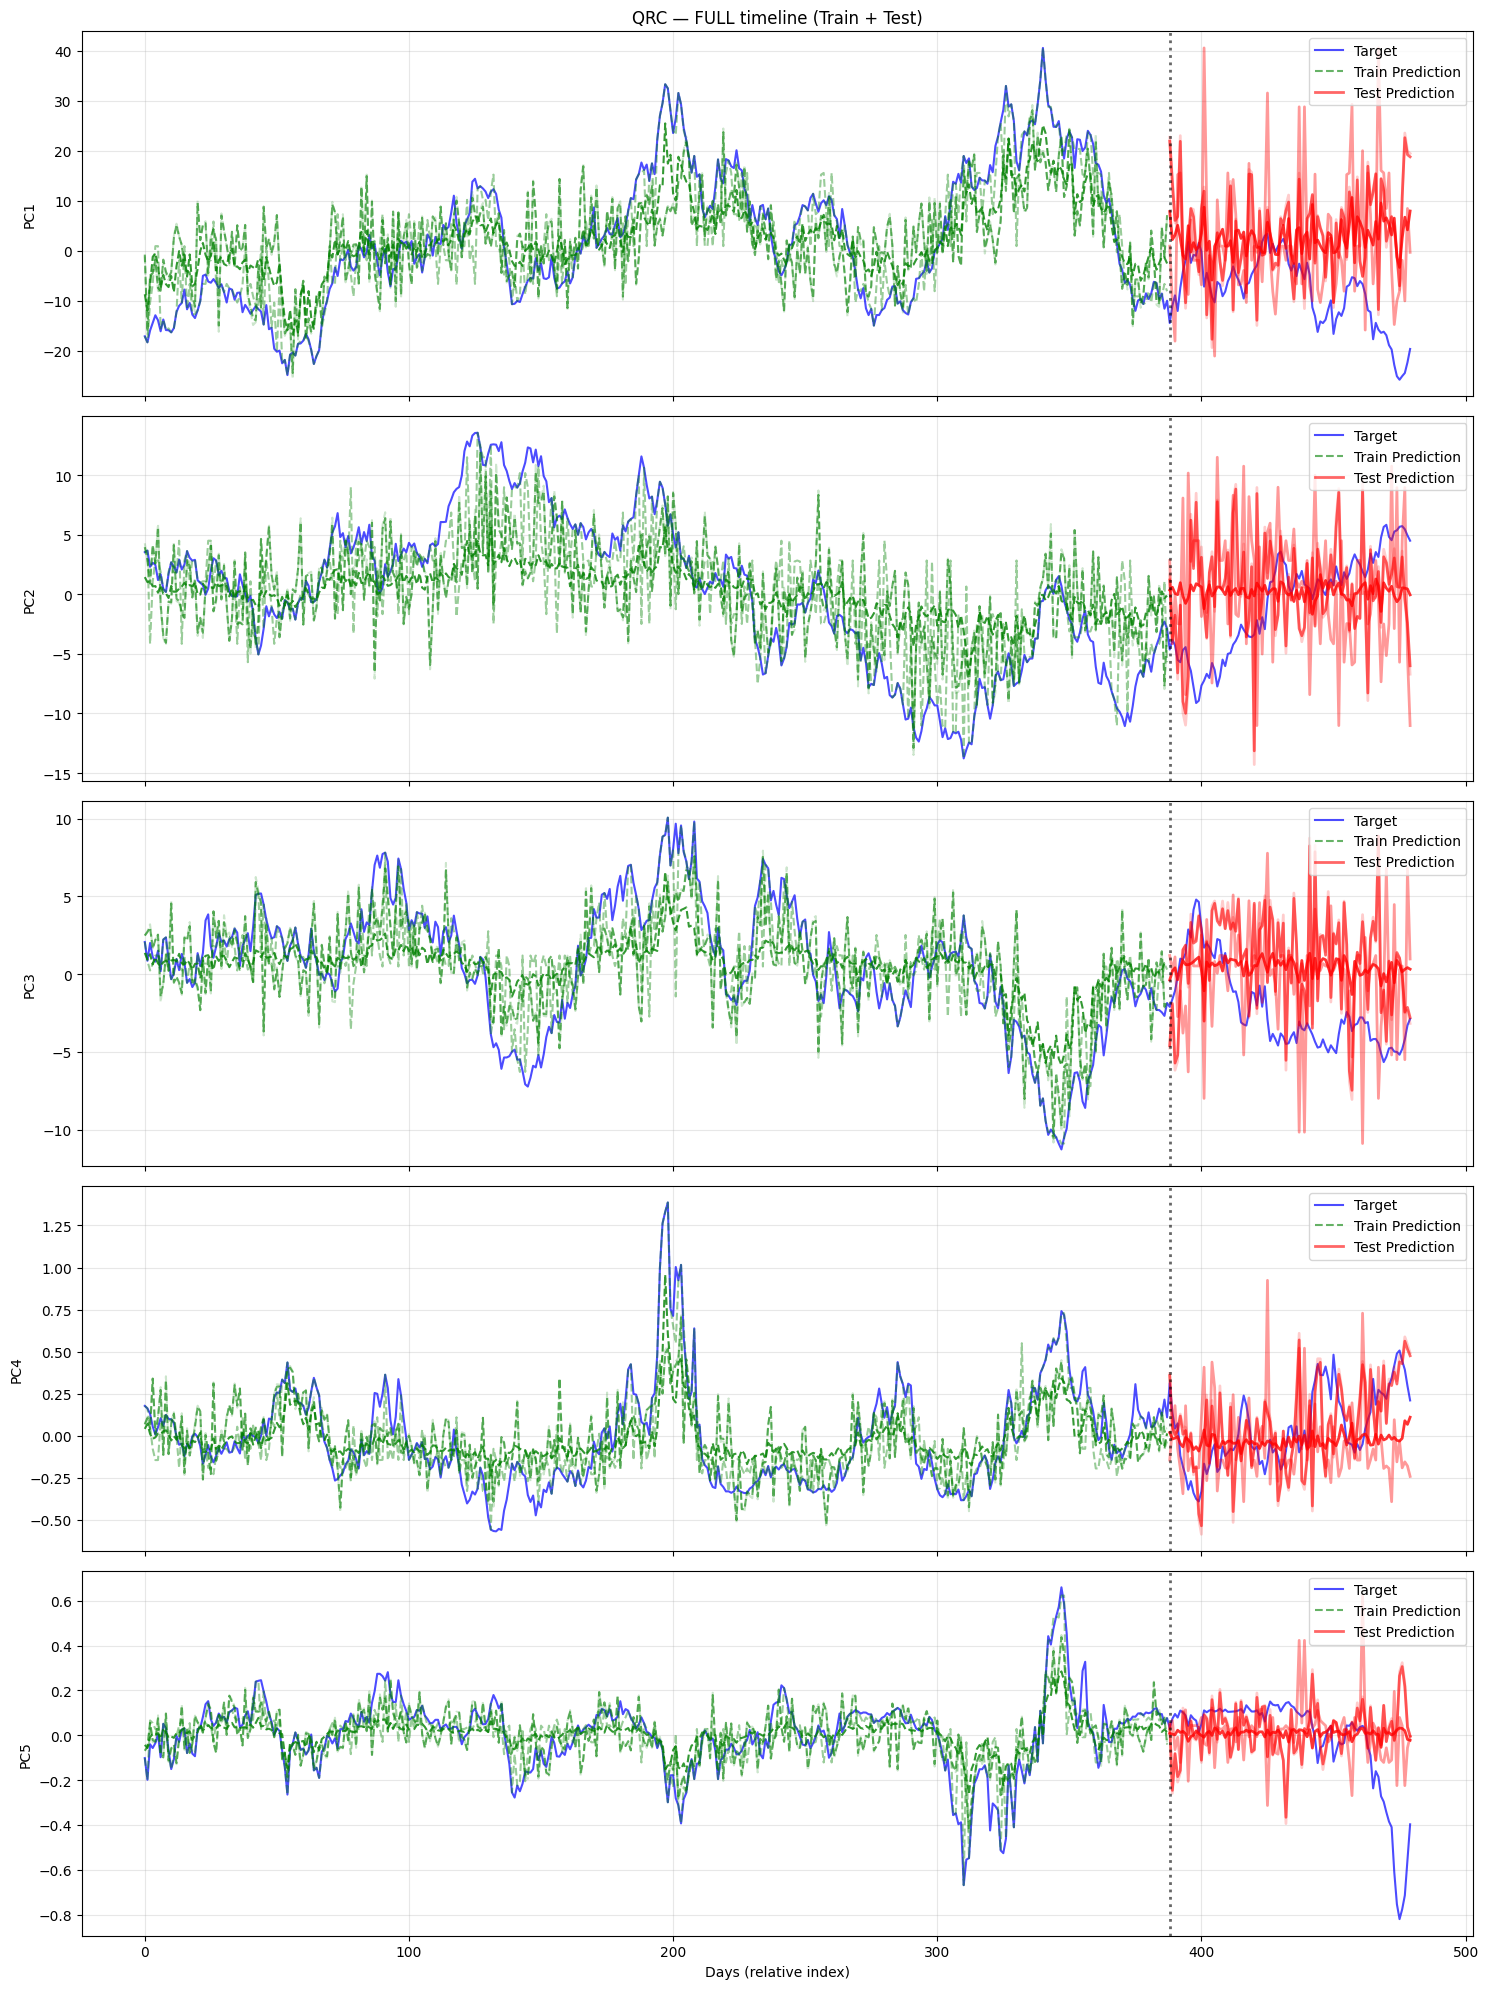

In [184]:
fig, axes = plt.subplots(n_components, 1, figsize=(15, 4 * n_components), sharex=True)
plt.subplots_adjust(hspace=0.1)

# Y_real_train_np = np.array(Y_real_train__last_epoch)

# Y_pred_train_np = np.array(Y_pred_train__last_epoch)
# Y_pred_train_np = np.array([t.detach().cpu().numpy() for t in Y_pred_train__last_epoch])

# Y_pred_train = Y_pred_train.detach().numpy()

# Days axis
days = np.arange(len(Y_train) + len(Y_test))

for i in range(n_components):
     ax = axes[i]
     
     # 1. Plot the Ground Truth (Target)
     ax.plot(days, Y_total[:, i], label='Target', color='blue', alpha=0.7, linewidth=1.5)
     once = False

     for name in predictions_np_train__for_plotting__all_readouts.keys():
        # 2. Plot Training Predictions
        # These correspond to the indices [0 : split_idx]
        train_days = days[:split_idx]
        ax.plot(train_days, predictions_np_train__for_plotting__all_readouts[name][:, i], label='Train Prediction' if once is False else None, 
                color='green', linestyle='--', alpha=alphas[name])
        
        # 3. Plot Test Predictions
        # These correspond to the indices [split_idx : ]
        #     test_days = days[split_idx:]
        test_days = days[split_idx:]
        ax.plot(test_days, predictions_np_test__for_plotting__all_readouts[name][:, i], label='Test Prediction' if once is False else None, 
                color='red', linewidth=2, alpha=alphas[name])
        
        once = True
        
     # 4. Vertical Divider line
     ax.axvline(x=split_idx, color='black', linestyle=':', linewidth=2, alpha=0.6)
    
     # Formatting
     ax.set_ylabel(f'PC{i+1}')
     ax.grid(True, which='both', linestyle='-', alpha=0.3)
     ax.legend(loc='upper right')
    
     # Set titles only for the top plot
     if i == 0:
        ax.set_title('QRC — FULL timeline (Train + Test)')

plt.xlabel('Days (relative index)')
plt.tight_layout()

plt.show()

NameError: name 'predictions_np_train__for_plotting__all_readouts__per_maturity' is not defined

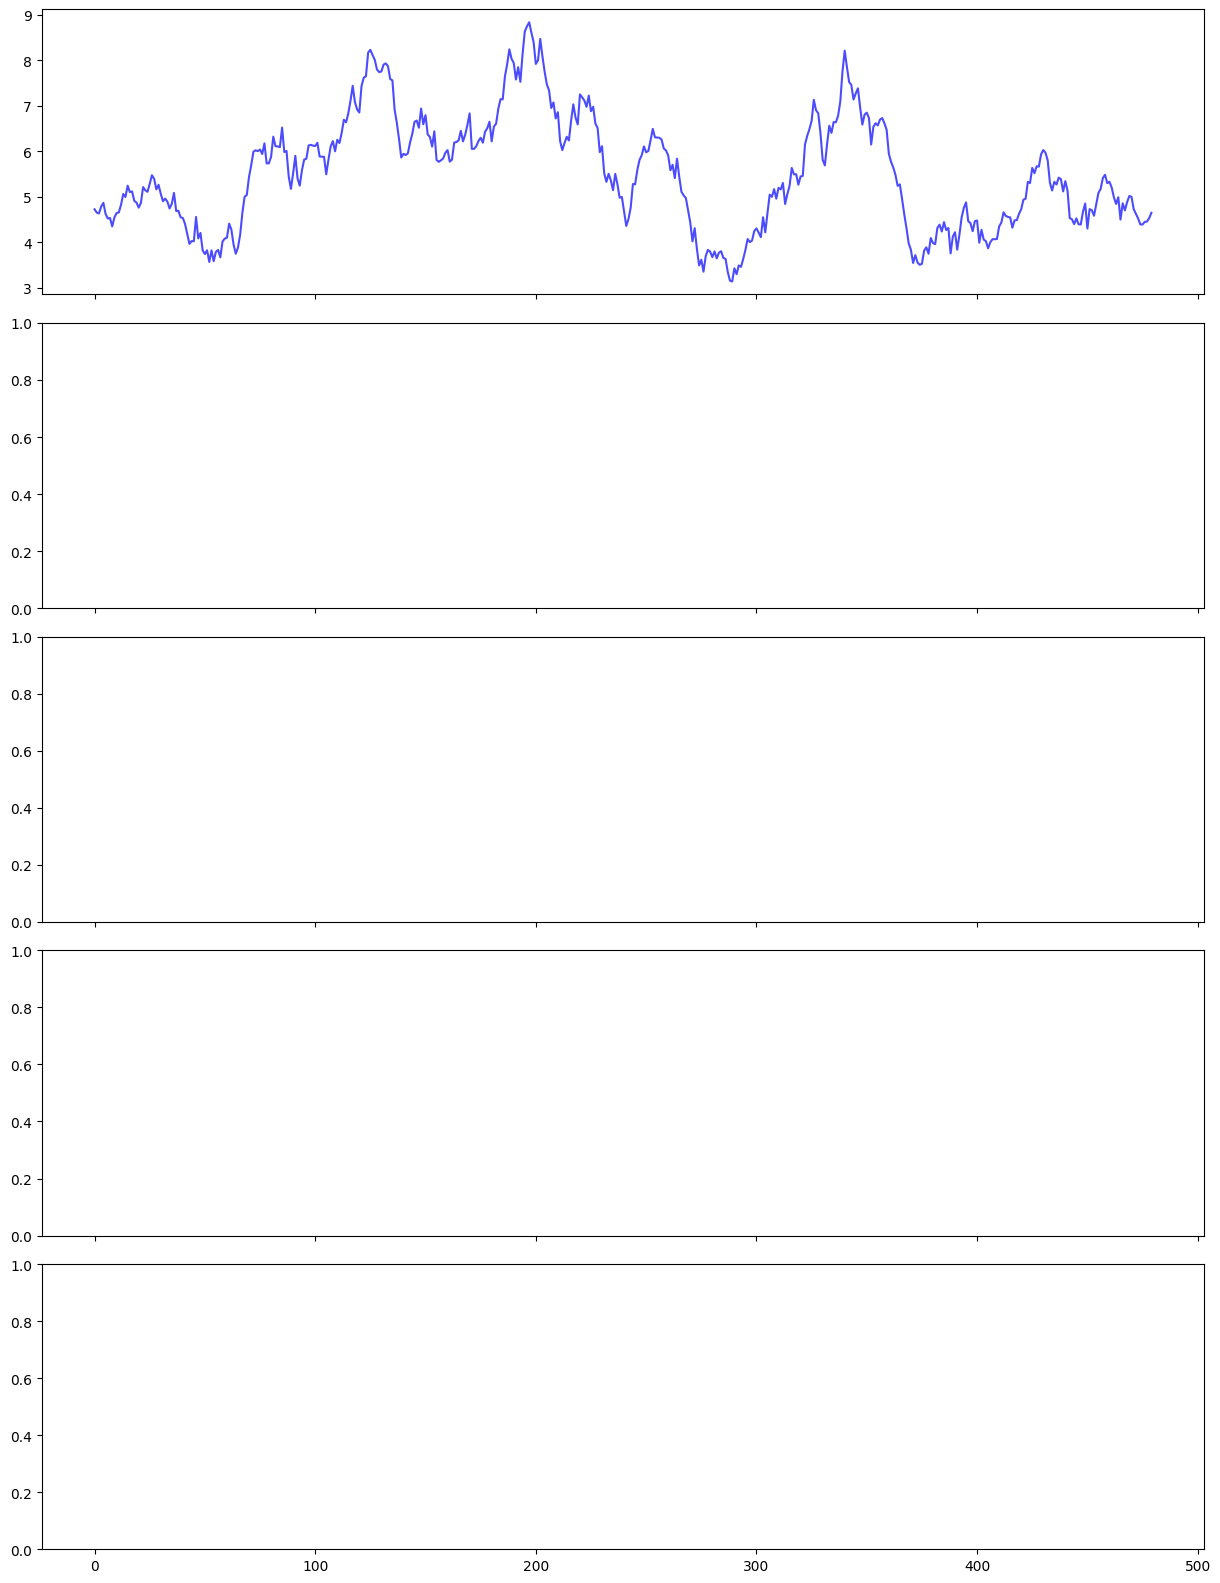

In [185]:
# for per-maturity

fig, axes = plt.subplots(n_components, 1, figsize=(15, 4 * n_components), sharex=True)
plt.subplots_adjust(hspace=0.1)

# Y_real_train_np = np.array(Y_real_train__last_epoch)

# Y_pred_train_np = np.array(Y_pred_train__last_epoch)
# Y_pred_train_np = np.array([t.detach().cpu().numpy() for t in Y_pred_train__last_epoch])

# Y_pred_train = Y_pred_train.detach().numpy()

# Days axis
days = np.arange(len(Y_train__per_maturity) + len(Y_test__per_maturity))

for i in range(n_components):
        ax = axes[i]
        
        # for maturity_idx in range(1):
        if True:
                maturity_idx = 15
                # 1. Plot the Ground Truth (Target)
                ax.plot(days, Y_total_per_maturity[:, maturity_idx, i], label='Target', color='blue', alpha=0.7, linewidth=1.5)
                once = False

                for name in predictions_np_train__for_plotting__all_readouts__per_maturity.keys():
                        # 2. Plot Training Predictions
                        # These correspond to the indices [0 : split_idx]
                        # print(predictions_np_train__for_plotting__all_readouts__per_maturity[name].shape)
                        train_days = days[:split_idx]
                        ax.plot(train_days, predictions_np_train__for_plotting__all_readouts__per_maturity[name][:, maturity_idx, i], label='Train Prediction' if once is False else None, 
                                color='green', linestyle='--', alpha=alphas[name])
                        
                        # 3. Plot Test Predictions
                        # These correspond to the indices [split_idx : ]
                        #     test_days = days[split_idx:]
                        test_days = days[split_idx:]
                        ax.plot(test_days, predictions_np_test__for_plotting__all_readouts__per_maturity[name][:, maturity_idx, i], label='Test Prediction' if once is False else None, 
                                color='red', linewidth=2, alpha=alphas[name])
                        
                        once = True
                        
                # 4. Vertical Divider line
                ax.axvline(x=split_idx, color='black', linestyle=':', linewidth=2, alpha=0.6)
                
                # Formatting
                ax.set_ylabel(f'PC{i+1}')
                ax.grid(True, which='both', linestyle='-', alpha=0.3)
                ax.legend(loc='upper right')
                
                # Set titles only for the top plot
                if i == 0:
                        ax.set_title('QRC — FULL timeline (Train + Test)')

plt.xlabel('Days (relative index)')
plt.tight_layout()
plt.show()

# Surface Plot

In [300]:
test_data_for_plot = predictions_np_train__for_plotting__all_readouts['Linear Regression']
test_data_for_plot.shape

(338, 5)

In [ ]:
day_idx = 95  # make sure this index exists

true_surface = reshape_surface(Y_test_surface[day_idx])
pred_surface = reshape_surface(Y_pred_surface[day_idx])

abs_error_surface = np.abs(true_surface - pred_surface)

vmin = min(true_surface.min(), pred_surface.min())
vmax = max(true_surface.max(), pred_surface.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c1 = axes[0].contourf(unique_tenors, unique_maturities,
                      true_surface.T,
                      levels=30,
                      vmin=vmin,
                      vmax=vmax,
                      cmap="viridis")
axes[0].set_title("True Surface")
fig.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(unique_tenors, unique_maturities,
                      pred_surface.T,
                      levels=30,
                      vmin=vmin,
                      vmax=vmax,
                      cmap="viridis")
axes[1].set_title("Predicted Surface")
fig.colorbar(c2, ax=axes[1])

c3 = axes[2].contourf(unique_tenors, unique_maturities,
                      abs_error_surface.T,
                      levels=30,
                      cmap="inferno")
axes[2].set_title("Absolute Error")
fig.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.show()

# Full final test on unseen 6 rows

In [301]:
full_final_test = np.array(pd.DataFrame(ds_full_df.drop(columns=["Date"]).loc[493:499, :]))
full_final_test.shape, type(full_final_test)

((7, 224), numpy.ndarray)

In [303]:
full_final_test__internal_init = np.array(pd.DataFrame(df.loc[493-window+1:493, :]))
full_final_test__internal_init.shape, type(full_final_test__internal_init)

((7, 224), numpy.ndarray)

In [308]:
full_final_test[0] == full_final_test__internal_init[-1]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,